# Exact MATLAB-reflection SLB-DNRM with model-driven highway animation

Upload `traffic_dataset.mat` and run all cells.

This version does **not** use decorative stock imagery. Every animated element is tied directly to optimized MILP results:

- freeway segment color <- density ratio $\rho/\rho_{crit}$
- number of freeway cars <- density ratio relative to jam density
- apparent vehicle drift <- mainline outflow relative to lane capacity
- ramp queue cars <- optimized queue level $Q$
- ramp meter circles <- optimized green/yellow/red shares within each cycle
- merge arrows <- optimized lane-level merge assignment $m$
- bottleneck highlight <- downstream slack and/or over-critical density


In [1]:
!pip install -q scipy pandas matplotlib imageio

In [ ]:
# If needed, upload the files manually from your computer.
# from google.colab import files
# files.upload()

In [3]:
%run slb_dnrm_exact_matlab_reflection_colab_highway_anim.py

Dataset: N=36, T=48, R=5, K=3, W=1
Cycle set: [45, 60, 90] seconds
Rolling window length: 8 intervals
Merge segment indices, 1-based as MATLAB phi: [3, 11, 19, 26, 34]

Window 1-8 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 1-8 | optimal_or_gap_feasible | obj=-5608.55 | solve=0.597s

Window 9-16 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 9-16 | optimal_or_gap_feasible | obj=3.70106e+06 | solve=0.230s

Window 17-24 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 17-24 | optimal_or_gap_feasible | obj=3.33161e+06 | solve=0.552s

Window 25-32 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 25-32 | optimal_or_gap_feasible | obj=1.17723e+07 | solve=0.707s

Window 33-40 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 33-40 | optimal_or_gap_feasible | obj=7.29632e+07 | solve=0.592s

Window 41-48 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 41-48 | optimal_or_gap_f

/content/slb_dnrm_exact_matlab_reflection_colab_highway_anim.py:876: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn_r')



DONE. Total rolling objective = 1.10315e+08
Completed in 3.69 seconds.
Saved folder: SLB_DNRM_Python_ExactOutputs
Saved animation: SLB_DNRM_Python_ExactOutputs/SLB_DNRM_exact_animation.gif
Saved ZIP: SLB_DNRM_Python_ExactOutputs.zip

Ramp-level summary:
 Ramp  RampLane  TotalDemandVeh  ServedVeh  UnmetVeh  ServicePercent  MaxQueueVeh  MaxOverflowVeh  IdleCapacityVeh  DownstreamSlackVeh  AvgRhoOverCriticalAtMerge  MaxRhoOverCriticalAtMerge  WindowServiceSlackVeh  ZeroReleaseIntervals
    1         1       2627.1184  2097.3641  831.4531         79.8352     635.2947        272.8070         120.0000              0.0000                     4.4377                        7.5               345.8485                    16
    2         1       4275.4018  3441.4464 1391.8464         80.4941    1136.4995        546.5830          82.5000              0.0265                     4.6654                        7.5               355.6954                    11
    3         1       3277.8969  3142.5619 

<Figure size 640x480 with 0 Axes>

In [10]:

# -*- coding: utf-8 -*-
"""
Exact-reflection Python/Colab port of the MATLAB SLB_DNRM_v7_Final MILP.

This script is intended to mirror the uploaded MATLAB implementation as closely as
possible while adding animation outputs. It uses scipy.optimize.milp / HiGHS.

Required files in the same folder or Colab working directory:
    traffic_dataset.mat

Outputs:
    SLB_DNRM_Python_ExactOutputs/
        SLB_DNRM_Rolling_Signal_Decisions.csv
        SLB_DNRM_Rolling_Traffic_States.csv
        SLB_DNRM_Rolling_Ramp_Summary.csv
        SLB_DNRM_Rolling_Merge_Assignment.csv
        SLB_DNRM_Rolling_Downstream_Slack.csv
        SLB_DNRM_Python_Exact_Results.npz
        SLB_DNRM_exact_animation.gif
        PNG figures

Colab install note:
    !pip install scipy pandas matplotlib imageio

Author: ChatGPT-generated Python port from user's MATLAB code.
"""

import os
import time
import math
import zipfile
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Tuple, List, Any

import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy import sparse
from scipy.optimize import milp, LinearConstraint, Bounds
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch


# ============================================================
# 1. PARAMETERS: SAME NUMERICAL VALUES AS MATLAB CODE
# ============================================================

@dataclass
class Params:
    datafile: str = "traffic_dataset.mat"
    sample_id: int = 1              # MATLAB uses 1-based sample id
    R: int = 5
    nMainLanes: int = 3
    rampLanes: List[int] = field(default_factory=list)
    dt: float = 0.25                # hours
    dtSec: float = 900              # seconds
    useAllScenarios: bool = False
    scenMult: List[float] = field(default_factory=lambda: [1.00])
    scenProb: List[float] = field(default_factory=lambda: [1.00])
    Hset: List[float] = field(default_factory=lambda: [45, 60, 90])
    window: int = 8
    maxTimeSec: float = 120
    relativeGap: float = 0.05
    displaySolver: bool = True
    minDemandServeFrac: float = 0.70
    minQueueServeFrac: float = 0.20
    windowServiceTarget: float = 0.80
    vFree: float = 62
    wCong: float = 15
    segLength: float = 0.80
    kJam: float = 7.5
    initDensityFracJam: float = 0.35
    targetMedQ: float = 1800
    satFlowRampLane: float = 900
    yellowMin: float = 3.0
    yellowMax: float = 6.0
    yellowFixed: float = 4.0
    greenMin: float = 2.0
    greenMaxFrac: float = 0.55
    redMin: float = 1.0
    redMaxFrac: float = 0.90
    storageMin: float = 60
    storageByCycle: float = 2.5
    allowTwoReceivingLanes: bool = True
    relaxReceivingLaneAssignment: bool = True
    adjacentReceivingMaxFrac: float = 0.60
    secondAdjacentReceivingMaxFrac: float = 0.25
    mergeFricMu: float = 0.07
    mergeDensityCoef: float = 5.0
    mergeThresholdFrac: float = 0.85

@dataclass
class Weights:
    unmet: float = 1000
    spill: float = 350
    queue: float = 15
    cong: float = 6
    merge: float = 2
    red: float = 0.20
    cycle: float = 0.05
    smoothC: float = 1.0
    smoothG: float = 0.50
    throughput: float = 0.05
    release: float = 5.0
    queueServiceSlack: float = 5000.0
    demandServiceSlack: float = 9000.0
    windowServiceSlack: float = 50000.0
    maxWindowServiceSlack: float = 15000.0
    idleCapacity: float = 40.0
    green: float = 0.05
    downstreamSlack: float = 3000.0


# ============================================================
# 2. UTILITY FUNCTIONS
# ============================================================

def matlab_prctile(x, q):
    """Approximate MATLAB prctile default using numpy linear percentile."""
    return np.percentile(x, q, method="linear")


def matlab_round(x):
    """MATLAB round: halves are rounded away from zero, unlike NumPy banker rounding."""
    x = np.asarray(x, dtype=float)
    return np.sign(x) * np.floor(np.abs(x) + 0.5)


def to_dense_array(obj):
    """Convert MATLAB/sparse object to dense numpy array."""
    if hasattr(obj, "toarray"):
        return np.asarray(obj.toarray(), dtype=float)
    return np.asarray(obj, dtype=float)


def extract_mat_cell_or_array(obj, sample_id_1based=1):
    """Replicate MATLAB: if iscell(Xtr), full(Xtr{sample_id}); else full(Xtr)."""
    arr = np.asarray(obj)
    if arr.dtype == object:
        flat = arr.ravel(order="F")
        sample_idx = int(sample_id_1based) - 1
        if sample_idx < 0 or sample_idx >= len(flat):
            raise IndexError(f"sample_id={sample_id_1based} outside MAT cell length {len(flat)}")
        return to_dense_array(flat[sample_idx])
    return to_dense_array(arr)


def add_block(n: int, dims: Tuple[int, ...]):
    size = int(np.prod(dims))
    arr = np.arange(n, n + size, dtype=int).reshape(dims, order="C")
    return arr, n + size


def arr_flat(a):
    return np.asarray(a, dtype=int).ravel(order="C")


def squeeze_keep(a):
    return np.asarray(a)


def make_outdir(base="SLB_DNRM_Python_ExactOutputs"):
    out = Path(base)
    out.mkdir(exist_ok=True)
    return out


# ============================================================
# 3. CALIBRATION: LINE-BY-LINE PORT OF MATLAB calibrateData
# ============================================================

def calibrate_data(p: Params, w: Weights, Araw, Xsample, Ytr, N, K, R, Amax, A_r, W, T, Hset, phi):
    Qproxy = np.max(Ytr, axis=1)
    Qproxy = np.maximum(Qproxy, 1e-6)
    scaleQ = 1.0
    if np.median(Qproxy) < 50:
        scaleQ = p.targetMedQ / np.median(Qproxy)
    Qseg = Qproxy * scaleQ
    Qlane = np.tile((Qseg.reshape(-1, 1) / K), (1, K))
    v = p.vFree * np.ones((N, K))
    wc = p.wCong * np.ones((N, K))
    L = p.segLength * np.ones(N)
    rhoCrit = Qlane / np.maximum(v, 1e-9)
    rhoJam = p.kJam * rhoCrit

    x = Xsample.ravel(order="F")
    x = x[np.isfinite(x)]
    xMin = matlab_prctile(x, 5)
    xMax = matlab_prctile(x, 95)
    if xMax <= xMin:
        xMax = xMin + 1

    rho0seg = np.zeros((N, T))
    for i in range(N):
        xi = Xsample[i, :].copy()
        xi = np.minimum(np.maximum(xi, xMin), xMax)
        xi = (xi - xMin) / (xMax - xMin + 1e-12)
        rho0seg[i, :] = p.initDensityFracJam * np.mean(rhoJam[i, :]) * xi

    rhoInit = np.zeros((N, K, W))
    for ww in range(W):
        for k in range(K):
            rhoInit[:, k, ww] = rho0seg[:, 0] / K * p.scenMult[ww]

    # phi is 0-based in Python; MATLAB used 1-based indices.
    uMaxRamp = np.minimum(np.maximum(0.50 * Qseg[phi], 350), 1100)

    sat = np.zeros((R, Amax))
    for r in range(R):
        sat[r, :A_r[r]] = p.satFlowRampLane

    Dbase = np.zeros((R, Amax, T))
    tgrid = np.arange(1, T + 1)
    for r in range(R):
        for a in range(A_r[r]):
            laneShare = 1.0 / A_r[r]
            peak1 = 0.70 * uMaxRamp[r] * laneShare * np.exp(-0.5 * ((tgrid - 16) / 5) ** 2)
            peak2 = 0.55 * uMaxRamp[r] * laneShare * np.exp(-0.5 * ((tgrid - 34) / 4) ** 2)
            wiggle = 0.08 * uMaxRamp[r] * laneShare * (1 + np.sin(2 * np.pi * (tgrid / 12 + (r + 1) / 7)))
            Dbase[r, a, :] = np.maximum(0, peak1 + peak2 + wiggle)

    D = np.zeros((R, Amax, T, W))
    for ww in range(W):
        D[:, :, :, ww] = Dbase * p.scenMult[ww]

    Cmax = np.zeros((R, Amax))
    for r in range(R):
        for a in range(A_r[r]):
            Cmax[r, a] = max(p.storageMin, p.storageByCycle * p.dt * (uMaxRamp[r] / A_r[r]))

    Qinit = np.zeros((R, Amax, W))

    chi = np.ones((N, K, T, W))
    incidentSeg = int(max(2, min(N - 1, matlab_round(0.58 * N)))) - 1  # MATLAB index to Python index
    for ww in range(W):
        if p.scenMult[ww] > 1:
            for tt in range(round(0.42 * T) - 1, round(0.62 * T)):
                if 0 <= tt < T:
                    chi[incidentSeg, :, tt, ww] = 0.78
                    if incidentSeg + 1 < N:
                        chi[incidentSeg + 1, :, tt, ww] = 0.85

    Qeff = np.zeros((N, K, T, W))
    for ww in range(W):
        for tt in range(T):
            Qeff[:, :, tt, ww] = chi[:, :, tt, ww] * Qlane

    eta = np.zeros((R, Amax, K))
    for r in range(R):
        for a in range(A_r[r]):
            eta[r, a, K - 1] = 1.00
            if p.relaxReceivingLaneAssignment and K >= 2:
                eta[r, a, K - 2] = p.adjacentReceivingMaxFrac
                if K >= 3:
                    eta[r, a, K - 3] = p.secondAdjacentReceivingMaxFrac
            elif p.allowTwoReceivingLanes and A_r[r] >= 2 and K >= 2:
                eta[r, a, K - 2] = 0.50
                eta[r, a, K - 1] = 0.50

    params = dict(Qlane=Qlane, v=v, wc=wc, L=L, rhoCrit=rhoCrit, rhoJam=rhoJam)
    return params, D, Qeff, rhoInit, Qinit, Cmax, sat, uMaxRamp, eta


# ============================================================
# 4. RESULTS CONTAINER
# ============================================================

def init_results(N, K, R, Amax, T, W):
    return dict(
        CycleSec=np.zeros((R, T)),
        G=np.zeros((R, Amax, T)),
        Y=np.zeros((R, Amax, T)),
        Red=np.zeros((R, Amax, T)),
        uCap=np.zeros((R, Amax, T)),
        u=np.zeros((R, Amax, T, W)),
        uRamp=np.zeros((R, T, W)),
        Q=np.zeros((R, Amax, T + 1, W)),
        O=np.zeros((R, Amax, T + 1, W)),
        UD=np.zeros((R, Amax, T, W)),
        qSlack=np.zeros((R, Amax, T, W)),
        dSlack=np.zeros((R, Amax, T, W)),
        idleCap=np.zeros((R, Amax, T, W)),
        m=np.zeros((R, Amax, K, T, W)),
        rho=np.zeros((N, K, T, W)),
        f=np.zeros((N, K, T, W)),
        e=np.zeros((N, K, T, W)),
        psi=np.zeros((R, K, T, W)),
        dsSlack=np.zeros((N, K, T, W)),
        winSlackTotal=np.zeros((R, Amax, W)),
        maxWinSlackTotal=np.zeros((W,)),
        objTotal=0.0,
        solveLog=[]
    )


# ============================================================
# 5. BUILD MILP: PORT OF MATLAB buildMILP
# ============================================================

def build_milp(p: Params, w: Weights, par: Dict[str, np.ndarray], D, Qeff, Qstart, rhoStart,
               prevC, prevG, Hset, phi, eta, Cmax, sat, uMaxRamp, A_r,
               N, K, R, Amax, T, W, Hn):
    n = 0
    idx = {}
    idx['z'], n = add_block(n, (R, Hn, T))
    idx['G'], n = add_block(n, (R, Amax, Hn, T))
    idx['Y'], n = add_block(n, (R, Amax, Hn, T))
    idx['Red'], n = add_block(n, (R, Amax, Hn, T))
    idx['C'], n = add_block(n, (R, T))
    idx['uCap'], n = add_block(n, (R, Amax, T))
    idx['u'], n = add_block(n, (R, Amax, T, W))
    idx['Q'], n = add_block(n, (R, Amax, T + 1, W))
    idx['O'], n = add_block(n, (R, Amax, T + 1, W))
    idx['UD'], n = add_block(n, (R, Amax, T, W))
    idx['qSlack'], n = add_block(n, (R, Amax, T, W))
    idx['dSlack'], n = add_block(n, (R, Amax, T, W))
    idx['idleCap'], n = add_block(n, (R, Amax, T, W))
    idx['winSlack'], n = add_block(n, (R, Amax, W))
    idx['maxWinSlack'], n = add_block(n, (W,))
    idx['m'], n = add_block(n, (R, Amax, K, T, W))
    idx['rho'], n = add_block(n, (N, K, T, W))
    idx['f'], n = add_block(n, (N, K, T, W))
    idx['e'], n = add_block(n, (N, K, T, W))
    idx['psi'], n = add_block(n, (R, K, T, W))
    idx['dsSlack'], n = add_block(n, (N, K, T, W))
    idx['dCp'], n = add_block(n, (R, T))
    idx['dCn'], n = add_block(n, (R, T))
    idx['dGp'], n = add_block(n, (R, Amax, T))
    idx['dGn'], n = add_block(n, (R, Amax, T))
    nx = n

    c = np.zeros(nx)
    lb = np.zeros(nx)
    ub = np.full(nx, np.inf)
    integrality = np.zeros(nx, dtype=int)
    integrality[arr_flat(idx['z'])] = 1
    ub[arr_flat(idx['z'])] = 1

    # Inactive ramp lanes fixed to zero.
    for r in range(R):
        for a in range(A_r[r], Amax):
            for key in ['G', 'Y', 'Red']:
                ub[arr_flat(idx[key][r, a, :, :])] = 0
            for key in ['uCap']:
                ub[arr_flat(idx[key][r, a, :])] = 0
            for key in ['u', 'Q', 'O', 'UD', 'qSlack', 'dSlack', 'idleCap', 'winSlack']:
                ub[arr_flat(idx[key][r, a, ...])] = 0
            ub[arr_flat(idx['m'][r, a, :, :, :])] = 0
            ub[arr_flat(idx['dGp'][r, a, :])] = 0
            ub[arr_flat(idx['dGn'][r, a, :])] = 0

    for r in range(R):
        for a in range(A_r[r]):
            val = min(uMaxRamp[r] / A_r[r], sat[r, a])
            ub[arr_flat(idx['uCap'][r, a, :])] = val
            ub[arr_flat(idx['u'][r, a, :, :])] = val

    for i in range(N):
        for k in range(K):
            ub[arr_flat(idx['rho'][i, k, :, :])] = par['rhoJam'][i, k]
            ub[arr_flat(idx['f'][i, k, :, :])] = max(par['Qlane'][i, k], np.max(Qeff[i, k, :, :]))

    def add_obj(vars_, coeff):
        c[arr_flat(vars_)] += coeff

    for ww in range(W):
        prob = p.scenProb[ww]
        add_obj(idx['UD'][:, :, :, ww], w.unmet * p.dt * prob)
        add_obj(idx['dSlack'][:, :, :, ww], w.demandServiceSlack * p.dt * prob)
        add_obj(idx['qSlack'][:, :, :, ww], w.queueServiceSlack * p.dt * prob)
        add_obj(idx['winSlack'][:, :, ww], w.windowServiceSlack * prob)
        add_obj(idx['maxWinSlack'][ww], w.maxWindowServiceSlack * prob)
        add_obj(idx['idleCap'][:, :, :, ww], w.idleCapacity * p.dt * prob)
        add_obj(idx['O'][:, :, :, ww], w.spill * prob)
        add_obj(idx['Q'][:, :, :, ww], w.queue * p.dt * prob)
        add_obj(idx['e'][:, :, :, ww], w.cong * prob)
        add_obj(idx['psi'][:, :, :, ww], w.merge * prob)
        add_obj(idx['dsSlack'][:, :, :, ww], w.downstreamSlack * prob)
        add_obj(idx['f'][:, :, :, ww], -w.throughput * p.dt * prob)
        add_obj(idx['u'][:, :, :, ww], -w.release * p.dt * prob)

    add_obj(idx['G'], w.green)
    add_obj(idx['Red'], w.red)
    add_obj(idx['C'], w.cycle)
    add_obj(idx['dCp'], w.smoothC)
    add_obj(idx['dCn'], w.smoothC)
    add_obj(idx['dGp'], w.smoothG)
    add_obj(idx['dGn'], w.smoothG)

    rows = []
    cols = []
    vals = []
    clb = []
    cub = []

    def add_row(vars_, coeffs, low, high):
        row = len(clb)
        v = np.asarray(vars_, dtype=int).ravel(order='C')
        a = np.asarray(coeffs, dtype=float).ravel(order='C')
        mask = np.abs(a) > 0
        v = v[mask]; a = a[mask]
        rows.extend([row] * len(v)); cols.extend(v.tolist()); vals.extend(a.tolist())
        clb.append(low); cub.append(high)

    def add_eq(vars_, coeffs, rhs):
        add_row(vars_, coeffs, rhs, rhs)

    def add_ineq(vars_, coeffs, rhs):
        add_row(vars_, coeffs, -np.inf, rhs)

    # Cycle-selection and cycle-smoothing constraints.
    for r in range(R):
        for t in range(T):
            zvars = idx['z'][r, :, t]
            add_eq(zvars, np.ones(Hn), 1)
            add_eq(np.r_[idx['C'][r, t], zvars], np.r_[1, -np.asarray(Hset)], 0)
            if t == 0:
                add_eq([idx['C'][r, t], idx['dCp'][r, t], idx['dCn'][r, t]], [1, -1, 1], prevC[r])
            else:
                add_eq([idx['C'][r, t], idx['C'][r, t - 1], idx['dCp'][r, t], idx['dCn'][r, t]], [1, -1, -1, 1], 0)

    # Signal timing and green smoothing.
    for r in range(R):
        for a in range(A_r[r]):
            for h in range(Hn):
                Cc = Hset[h]
                for t in range(T):
                    z = idx['z'][r, h, t]
                    G = idx['G'][r, a, h, t]
                    Y = idx['Y'][r, a, h, t]
                    Re = idx['Red'][r, a, h, t]
                    add_eq([G, Y, Re, z], [1, 1, 1, -Cc], 0)
                    add_ineq([G, z], [-1, p.greenMin], 0)
                    add_ineq([G, z], [1, -p.greenMaxFrac * Cc], 0)
                    add_eq([Y, z], [1, -p.yellowFixed], 0)
                    add_ineq([Re, z], [-1, p.redMin], 0)
                    add_ineq([Re, z], [1, -p.redMaxFrac * Cc], 0)
            for t in range(T):
                vars_ = [idx['uCap'][r, a, t]]
                coeffs = [1]
                for h in range(Hn):
                    vars_.append(idx['G'][r, a, h, t])
                    coeffs.append(-sat[r, a] / Hset[h])
                add_eq(vars_, coeffs, 0)

                Gvars = idx['G'][r, a, :, t]
                if t == 0:
                    add_eq(np.r_[Gvars, idx['dGp'][r, a, t], idx['dGn'][r, a, t]],
                           np.r_[np.ones(Hn), -1, 1], prevG[r, a])
                else:
                    Gprev = idx['G'][r, a, :, t - 1]
                    add_eq(np.r_[Gvars, Gprev, idx['dGp'][r, a, t], idx['dGn'][r, a, t]],
                           np.r_[np.ones(Hn), -np.ones(Hn), -1, 1], 0)

    # Ramp queue, demand service, merge split constraints.
    for r in range(R):
        for a in range(A_r[r]):
            for ww in range(W):
                add_eq([idx['Q'][r, a, 0, ww]], [1], Qstart[r, a, ww])
                for t in range(T):
                    add_ineq([idx['u'][r, a, t, ww], idx['uCap'][r, a, t]], [1, -1], 0)
                    add_ineq([idx['idleCap'][r, a, t, ww], idx['uCap'][r, a, t], idx['u'][r, a, t, ww]], [-1, 1, -1], 0)
                    add_eq([idx['Q'][r, a, t + 1, ww], idx['Q'][r, a, t, ww], idx['u'][r, a, t, ww]],
                           [1, -1, p.dt], p.dt * D[r, a, t, ww])
                    add_ineq([idx['Q'][r, a, t, ww], idx['O'][r, a, t, ww]], [1, -1], Cmax[r, a])
                    add_ineq([idx['u'][r, a, t, ww], idx['Q'][r, a, t, ww]], [1, -1 / p.dt], D[r, a, t, ww])
                    add_ineq([idx['u'][r, a, t, ww], idx['UD'][r, a, t, ww]], [-1, -1], -D[r, a, t, ww])
                    add_ineq([idx['u'][r, a, t, ww], idx['dSlack'][r, a, t, ww]], [-1, -1], -p.minDemandServeFrac * D[r, a, t, ww])
                    add_ineq([idx['u'][r, a, t, ww], idx['qSlack'][r, a, t, ww], idx['Q'][r, a, t, ww]],
                             [-1, -1, p.minQueueServeFrac / p.dt], 0)
                    mvars = idx['m'][r, a, :, t, ww]
                    add_eq(np.r_[mvars, idx['u'][r, a, t, ww]], np.r_[np.ones(K), -1], 0)
                    for k in range(K):
                        if eta[r, a, k] <= 0:
                            add_eq([idx['m'][r, a, k, t, ww]], [1], 0)
                        else:
                            add_ineq([idx['m'][r, a, k, t, ww], idx['u'][r, a, t, ww]], [1, -eta[r, a, k]], 0)
                add_ineq([idx['Q'][r, a, T, ww], idx['O'][r, a, T, ww]], [1, -1], Cmax[r, a])
                uvars = idx['u'][r, a, :, ww]
                demandVeh = p.dt * np.sum(D[r, a, :, ww])
                add_ineq(np.r_[uvars, idx['winSlack'][r, a, ww]], np.r_[-p.dt * np.ones(T), -1], -p.windowServiceTarget * demandVeh)
                add_ineq([idx['winSlack'][r, a, ww], idx['maxWinSlack'][ww]], [1, -1], 0)

    # Mainline traffic flow constraints.
    for i in range(N):
        for k in range(K):
            for ww in range(W):
                add_eq([idx['rho'][i, k, 0, ww]], [1], rhoStart[i, k, ww])
                for t in range(T):
                    add_ineq([idx['f'][i, k, t, ww], idx['rho'][i, k, t, ww]], [1, -par['v'][i, k]], 0)
                    add_ineq([idx['f'][i, k, t, ww]], [1], Qeff[i, k, t, ww])
                    if i < N - 1:
                        add_ineq([idx['f'][i, k, t, ww], idx['rho'][i + 1, k, t, ww], idx['dsSlack'][i, k, t, ww]],
                                 [1, par['wc'][i + 1, k], -1], par['wc'][i + 1, k] * par['rhoJam'][i + 1, k])
                    add_ineq([idx['rho'][i, k, t, ww], idx['e'][i, k, t, ww]], [1, -1], par['rhoCrit'][i, k])
                for t in range(T - 1):
                    vars_ = [idx['rho'][i, k, t + 1, ww], idx['rho'][i, k, t, ww], idx['f'][i, k, t, ww]]
                    coeffs = [1, -1, p.dt / par['L'][i]]
                    if i > 0:
                        vars_.append(idx['f'][i - 1, k, t, ww]); coeffs.append(-p.dt / par['L'][i])
                    for rr in range(R):
                        if phi[rr] == i:
                            for a in range(A_r[rr]):
                                vars_.append(idx['m'][rr, a, k, t, ww]); coeffs.append(-p.dt / par['L'][i])
                    add_eq(vars_, coeffs, 0)

    # Merge friction constraints.
    for r in range(R):
        iseg = phi[r]
        for k in range(K):
            for t in range(T):
                for ww in range(W):
                    vars_ = [idx['psi'][r, k, t, ww], idx['rho'][iseg, k, t, ww]]
                    coeffs = [-1, p.mergeDensityCoef]
                    for a in range(A_r[r]):
                        vars_.append(idx['m'][r, a, k, t, ww]); coeffs.append(1)
                    rhs = p.mergeThresholdFrac * Qeff[iseg, k, t, ww] + p.mergeDensityCoef * par['rhoCrit'][iseg, k]
                    add_ineq(vars_, coeffs, rhs)
                    add_ineq([idx['f'][iseg, k, t, ww], idx['psi'][r, k, t, ww]], [1, p.mergeFricMu], Qeff[iseg, k, t, ww])

    A = sparse.coo_matrix((vals, (rows, cols)), shape=(len(clb), nx)).tocsr()
    constraints = LinearConstraint(A, np.asarray(clb, dtype=float), np.asarray(cub, dtype=float))
    bounds = Bounds(lb, ub)
    return c, integrality, bounds, constraints, idx, nx, A.shape[0]


# ============================================================
# 6. DECODE AND STORE WINDOW SOLUTION
# ============================================================

def decode_window(x, idx, N, K, R, Amax, T, W, Hn, Hset):
    win = dict(
        CycleSec=np.zeros((R, T)),
        G=np.zeros((R, Amax, Hn, T)),
        Y=np.zeros((R, Amax, Hn, T)),
        Red=np.zeros((R, Amax, Hn, T)),
        uCap=np.zeros((R, Amax, T)),
        u=np.zeros((R, Amax, T, W)),
        Q=np.zeros((R, Amax, T + 1, W)),
        O=np.zeros((R, Amax, T + 1, W)),
        UD=np.zeros((R, Amax, T, W)),
        qSlack=np.zeros((R, Amax, T, W)),
        dSlack=np.zeros((R, Amax, T, W)),
        idleCap=np.zeros((R, Amax, T, W)),
        winSlack=np.zeros((R, Amax, W)),
        maxWinSlack=np.zeros((W,)),
        m=np.zeros((R, Amax, K, T, W)),
        rho=np.zeros((N, K, T, W)),
        f=np.zeros((N, K, T, W)),
        e=np.zeros((N, K, T, W)),
        psi=np.zeros((R, K, T, W)),
        dsSlack=np.zeros((N, K, T, W)),
    )
    for r in range(R):
        for t in range(T):
            win['CycleSec'][r, t] = x[idx['C'][r, t]]
            for a in range(Amax):
                win['uCap'][r, a, t] = x[idx['uCap'][r, a, t]]
                for h in range(Hn):
                    win['G'][r, a, h, t] = x[idx['G'][r, a, h, t]]
                    win['Y'][r, a, h, t] = x[idx['Y'][r, a, h, t]]
                    win['Red'][r, a, h, t] = x[idx['Red'][r, a, h, t]]
                for ww in range(W):
                    win['u'][r, a, t, ww] = x[idx['u'][r, a, t, ww]]
                    win['UD'][r, a, t, ww] = x[idx['UD'][r, a, t, ww]]
                    win['qSlack'][r, a, t, ww] = x[idx['qSlack'][r, a, t, ww]]
                    win['dSlack'][r, a, t, ww] = x[idx['dSlack'][r, a, t, ww]]
                    win['idleCap'][r, a, t, ww] = x[idx['idleCap'][r, a, t, ww]]
                    for k in range(K):
                        win['m'][r, a, k, t, ww] = x[idx['m'][r, a, k, t, ww]]
        for a in range(Amax):
            for tt in range(T + 1):
                for ww in range(W):
                    win['Q'][r, a, tt, ww] = x[idx['Q'][r, a, tt, ww]]
                    win['O'][r, a, tt, ww] = x[idx['O'][r, a, tt, ww]]
            for ww in range(W):
                win['winSlack'][r, a, ww] = x[idx['winSlack'][r, a, ww]]
    for ww in range(W):
        win['maxWinSlack'][ww] = x[idx['maxWinSlack'][ww]]

    for i in range(N):
        for k in range(K):
            for t in range(T):
                for ww in range(W):
                    win['rho'][i, k, t, ww] = x[idx['rho'][i, k, t, ww]]
                    win['f'][i, k, t, ww] = x[idx['f'][i, k, t, ww]]
                    win['e'][i, k, t, ww] = x[idx['e'][i, k, t, ww]]
                    win['dsSlack'][i, k, t, ww] = x[idx['dsSlack'][i, k, t, ww]]
    for r in range(R):
        for k in range(K):
            for t in range(T):
                for ww in range(W):
                    win['psi'][r, k, t, ww] = x[idx['psi'][r, k, t, ww]]

    win['Gsum'] = np.sum(win['G'], axis=2)
    win['Ysum'] = np.sum(win['Y'], axis=2)
    win['RedSum'] = np.sum(win['Red'], axis=2)
    return win


def store_window(res, win, t0, t1, W):
    # t0,t1 Python inclusive positions.
    loc = np.arange(0, t1 - t0 + 1)
    res['CycleSec'][:, t0:t1 + 1] = win['CycleSec']
    res['G'][:, :, t0:t1 + 1] = win['Gsum']
    res['Y'][:, :, t0:t1 + 1] = win['Ysum']
    res['Red'][:, :, t0:t1 + 1] = win['RedSum']
    res['uCap'][:, :, t0:t1 + 1] = win['uCap']
    res['u'][:, :, t0:t1 + 1, :] = win['u']
    res['uRamp'][:, t0:t1 + 1, :] = np.sum(win['u'], axis=1)
    res['Q'][:, :, t0:t1 + 1, :] = win['Q'][:, :, loc, :]
    res['Q'][:, :, t1 + 1, :] = win['Q'][:, :, -1, :]
    res['O'][:, :, t0:t1 + 1, :] = win['O'][:, :, loc, :]
    res['O'][:, :, t1 + 1, :] = win['O'][:, :, -1, :]
    res['UD'][:, :, t0:t1 + 1, :] = win['UD']
    res['qSlack'][:, :, t0:t1 + 1, :] = win['qSlack']
    res['dSlack'][:, :, t0:t1 + 1, :] = win['dSlack']
    res['idleCap'][:, :, t0:t1 + 1, :] = win['idleCap']
    res['m'][:, :, :, t0:t1 + 1, :] = win['m']
    res['rho'][:, :, t0:t1 + 1, :] = win['rho']
    res['f'][:, :, t0:t1 + 1, :] = win['f']
    res['e'][:, :, t0:t1 + 1, :] = win['e']
    res['psi'][:, :, t0:t1 + 1, :] = win['psi']
    res['dsSlack'][:, :, t0:t1 + 1, :] = win['dsSlack']
    res['winSlackTotal'] += win['winSlack']
    res['maxWinSlackTotal'] += win['maxWinSlack']
    return res


# ============================================================
# 7. TABLES: PORT OF MATLAB OUTPUT TABLES
# ============================================================

def make_signal_table(res, R, Amax, T):
    rows = []
    for r in range(R):
        for a in range(Amax):
            for t in range(T):
                rows.append([r+1, a+1, t+1, res['CycleSec'][r,t], res['G'][r,a,t], res['Y'][r,a,t], res['Red'][r,a,t],
                             res['uCap'][r,a,t], res['u'][r,a,t,0], res['Q'][r,a,t,0], res['UD'][r,a,t,0],
                             res['qSlack'][r,a,t,0], res['dSlack'][r,a,t,0], res['idleCap'][r,a,t,0], res['O'][r,a,t,0]])
    return pd.DataFrame(rows, columns=['Ramp','RampLane','Time','CycleSec','GreenSec','YellowSec','RedSec','ReleaseCapVehHr','ActualReleaseVehHr','QueueVeh','UnmetDemandVehHr','QueueServiceSlack','DemandServiceSlack','IdleCapacityVehHr','OverflowVeh'])


def make_ramp_summary(res, D, R, Amax, T):
    rows = []
    p = res['p']; phi = res['phi']; params = res['params']
    for r in range(R):
        for a in range(Amax):
            demand = np.sum(D[r,a,0:T,0]) * p.dt
            served = np.sum(res['u'][r,a,0:T,0]) * p.dt
            unmet = np.sum(res['UD'][r,a,0:T,0]) * p.dt
            qmax = np.max(res['Q'][r,a,0:T,0])
            omax = np.max(res['O'][r,a,0:T,0])
            rel0 = np.sum(res['u'][r,a,0:T,0] < 1e-5)
            idle = np.sum(res['idleCap'][r,a,0:T,0]) * p.dt
            iseg = phi[r]
            ds = np.sum(res['dsSlack'][iseg,:,0:T,0]) * p.dt
            ratio = res['rho'][iseg,:,0:T,0] / np.maximum(params['rhoCrit'][iseg,:], 1e-9)[:,None]
            maxRhoCrit = np.max(ratio)
            avgRhoCrit = np.mean(ratio)
            serviceSlack = res['winSlackTotal'][r,a,0]
            servicePct = 100 * served / max(demand, 1e-9)
            rows.append([r+1,a+1,demand,served,unmet,servicePct,qmax,omax,idle,ds,avgRhoCrit,maxRhoCrit,serviceSlack,rel0])
    return pd.DataFrame(rows, columns=['Ramp','RampLane','TotalDemandVeh','ServedVeh','UnmetVeh','ServicePercent','MaxQueueVeh','MaxOverflowVeh','IdleCapacityVeh','DownstreamSlackVeh','AvgRhoOverCriticalAtMerge','MaxRhoOverCriticalAtMerge','WindowServiceSlackVeh','ZeroReleaseIntervals'])


def make_merge_assignment_table(res, R, Amax, K, T):
    rows = []
    for r in range(R):
        for a in range(Amax):
            totalRelease = np.sum(res['u'][r,a,0:T,0]) * res['p'].dt
            laneVeh = np.array([np.sum(res['m'][r,a,k,0:T,0]) * res['p'].dt for k in range(K)])
            lanePct = 100 * laneVeh / max(totalRelease, 1e-9)
            rows.append([r+1,a+1,totalRelease,*laneVeh,*lanePct])
    names = ['Ramp','RampLane','TotalReleaseVeh'] + [f'MergeLane{k+1}Veh' for k in range(K)] + [f'MergeLane{k+1}Percent' for k in range(K)]
    return pd.DataFrame(rows, columns=names)


def make_traffic_table(res, N, K, T, W, phi):
    rows = []
    keep = sorted(set(phi.tolist()))
    for i in keep:
        for k in range(K):
            for t in range(T):
                rows.append([i+1,k+1,t+1,res['rho'][i,k,t,0],res['f'][i,k,t,0],res['e'][i,k,t,0],res['dsSlack'][i,k,t,0]])
    return pd.DataFrame(rows, columns=['Segment','Lane','Time','DensityVehMiLane','OutflowVehHr','ExcessDensity','DownstreamSlackVehHr'])


def make_downstream_slack_table(res, phi, R, K, T):
    rows = []
    p = res['p']; params = res['params']
    for r in range(R):
        iseg = phi[r]
        for k in range(K):
            dsTotal = np.sum(res['dsSlack'][iseg,k,0:T,0]) * p.dt
            dsMax = np.max(res['dsSlack'][iseg,k,0:T,0])
            rhoRatio = res['rho'][iseg,k,0:T,0] / max(params['rhoCrit'][iseg,k], 1e-9)
            avgRho = np.mean(rhoRatio)
            maxRho = np.max(rhoRatio)
            avgExcess = np.mean(res['e'][iseg,k,0:T,0])
            rows.append([r+1, iseg+1, k+1, dsTotal, dsMax, avgRho, maxRho, avgExcess])
    return pd.DataFrame(rows, columns=['Ramp','MergeSegment','Lane','DownstreamSlackVeh','MaxDownstreamSlackVehHr','AvgRhoOverCritical','MaxRhoOverCritical','AvgExcessDensity'])


def make_overall_metrics(res, summary):
    totalDemand = summary['TotalDemandVeh'].sum()
    served = summary['ServedVeh'].sum()
    unmet = summary['UnmetVeh'].sum()
    weightedService = 100 * served / max(totalDemand, 1e-9)
    minService = summary['ServicePercent'].min()
    maxQueue = summary['MaxQueueVeh'].max()
    maxOverflow = summary['MaxOverflowVeh'].max()
    zeroRelease = summary['ZeroReleaseIntervals'].sum()
    ds = summary['DownstreamSlackVeh'].sum() if 'DownstreamSlackVeh' in summary else 0
    rhoCrit = res['params']['rhoCrit']
    rhoRatio = res['rho'][:,:,:,0] / rhoCrit[:,:,None]
    meanRho = np.mean(rhoRatio)
    maxRho = np.max(rhoRatio)
    return pd.DataFrame([[totalDemand,served,unmet,weightedService,minService,maxQueue,maxOverflow,zeroRelease,ds,meanRho,maxRho,res['objTotal']]],
                        columns=['TotalDemandVeh','TotalServedVeh','TotalUnmetVeh','WeightedServicePercent','MinimumRampServicePercent','MaximumQueueVeh','MaximumOverflowVeh','TotalZeroReleaseIntervals','TotalDownstreamSlackVeh','MeanRhoOverCritical','MaxRhoOverCritical','TotalRollingObjective'])


# ============================================================
# 8. FIGURES AND ANIMATION
# ============================================================

def save_static_figures(res, summaryTable, mergeTable, outDir):
    figDir = Path(outDir) / 'Figures'
    figDir.mkdir(exist_ok=True)
    # Use Times New Roman if available; otherwise matplotlib falls back automatically.
    plt.rcParams['font.size'] = 12
    R = res['u'].shape[0]; T = res['u'].shape[2]; K = res['rho'].shape[1]
    timev = np.arange(1, T+1)
    phi = res['phi']

    f, ax = plt.subplots(figsize=(7,4), facecolor='white')
    ax.bar(summaryTable['Ramp'], summaryTable['ServicePercent'])
    ax.axhline(80, linestyle='--', color='k', linewidth=1.2)
    ax.grid(True); ax.set_xlabel('Ramp'); ax.set_ylabel('Demand served (%)'); ax.set_title('Ramp-level demand service performance')
    f.tight_layout(); f.savefig(figDir/'Fig_1_Ramp_Service_Percent.png', dpi=300); plt.close(f)

    f, ax = plt.subplots(figsize=(7,4), facecolor='white')
    ax.bar(summaryTable['Ramp']-0.18, summaryTable['MaxQueueVeh'], width=0.36, label='Maximum queue')
    ax.bar(summaryTable['Ramp']+0.18, summaryTable['MaxOverflowVeh'], width=0.36, label='Maximum overflow')
    ax.grid(True); ax.set_xlabel('Ramp'); ax.set_ylabel('Vehicles'); ax.set_title('Maximum ramp queue and overflow'); ax.legend()
    f.tight_layout(); f.savefig(figDir/'Fig_2_Queue_Overflow_ByRamp.png', dpi=300); plt.close(f)

    f, ax = plt.subplots(figsize=(8,4), facecolor='white')
    lane_cols = [c for c in mergeTable.columns if c.startswith('MergeLane') and c.endswith('Percent')]
    bottom = np.zeros(len(mergeTable))
    for j,c in enumerate(lane_cols):
        ax.bar(mergeTable['Ramp'], mergeTable[c], bottom=bottom, label=f'Lane {j+1}')
        bottom += mergeTable[c].to_numpy()
    ax.grid(True); ax.set_xlabel('Ramp'); ax.set_ylabel('Merge assignment (%)'); ax.set_title('Lane-level merge assignment of released ramp flow'); ax.legend(loc='center left', bbox_to_anchor=(1,0.5))
    f.tight_layout(); f.savefig(figDir/'Fig_3_Merge_Lane_Assignment.png', dpi=300); plt.close(f)

    rhoAgg = np.sum(res['rho'][:,:,:,0], axis=1)
    f, ax = plt.subplots(figsize=(8,5), facecolor='white')
    im = ax.imshow(rhoAgg, aspect='auto', origin='lower', extent=[1,T,1,rhoAgg.shape[0]])
    f.colorbar(im, ax=ax); ax.grid(False); ax.set_xlabel('Time interval'); ax.set_ylabel('Highway segment'); ax.set_title('Lane-aggregated mainline density')
    ax.plot(np.arange(1,T+1), np.repeat(phi[:,None]+1, T, axis=1).T, '.', markersize=3, color='k')
    f.tight_layout(); f.savefig(figDir/'Fig_4_Mainline_Density_Heatmap.png', dpi=300); plt.close(f)

    rhoCrit = res['params']['rhoCrit']; N = res['rho'].shape[0]
    rhoRatio = np.zeros((N,T))
    for i in range(N):
        rhoRatio[i,:] = np.mean(res['rho'][i,:,0:T,0] / np.maximum(rhoCrit[i,:], 1e-9)[:,None], axis=0)
    f, ax = plt.subplots(figsize=(8,5), facecolor='white')
    im = ax.imshow(rhoRatio, aspect='auto', origin='lower', extent=[1,T,1,N])
    f.colorbar(im, ax=ax); ax.set_xlabel('Time interval'); ax.set_ylabel('Highway segment'); ax.set_title('Mean lane density divided by critical density')
    f.tight_layout(); f.savefig(figDir/'Fig_5_Rho_Over_Critical_Heatmap.png', dpi=300); plt.close(f)

    f, axs = plt.subplots(R, 1, figsize=(8, 1.8*R), sharex=True, facecolor='white')
    if R == 1: axs = [axs]
    for r, ax in enumerate(axs):
        rel = res['uRamp'][r,:,0]
        q = np.sum(res['Q'][r,:,0:T,0], axis=0)
        ax.plot(timev, rel, linewidth=1.2, label='Release veh/h')
        ax2 = ax.twinx()
        ax2.plot(timev, q, '--', linewidth=1.2, label='Queue veh')
        ax.grid(True); ax.set_title(f'Ramp {r+1}'); ax.set_ylabel('Release')
        ax2.set_ylabel('Queue')
    axs[-1].set_xlabel('Time interval')
    f.tight_layout(); f.savefig(figDir/'Fig_6_Ramp_Release_Queue_TimeSeries.png', dpi=300); plt.close(f)

    f, axs = plt.subplots(R, 1, figsize=(8, 1.8*R), sharex=True, facecolor='white')
    if R == 1: axs = [axs]
    for r, ax in enumerate(axs):
        ax.plot(timev, res['G'][r,0,:], linewidth=1.2, label='Green')
        ax.plot(timev, res['Y'][r,0,:], '--', linewidth=1.2, label='Yellow')
        ax.plot(timev, res['Red'][r,0,:], ':', linewidth=1.5, label='Red')
        ax.grid(True); ax.set_title(f'Ramp {r+1} signal timing'); ax.set_ylabel('Seconds')
        if r == 0: ax.legend(loc='center left', bbox_to_anchor=(1,0.5))
    axs[-1].set_xlabel('Time interval')
    f.tight_layout(); f.savefig(figDir/'Fig_7_Signal_Timing_TimeSeries.png', dpi=300); plt.close(f)

    f, ax = plt.subplots(figsize=(8,4), facecolor='white')
    ax.plot(timev, res['CycleSec'].T, linewidth=1.2)
    ax.grid(True); ax.set_xlabel('Time interval'); ax.set_ylabel('Cycle length (s)'); ax.set_title('Selected cycle length by ramp')
    ax.legend([f'Ramp {i+1}' for i in range(R)], loc='center left', bbox_to_anchor=(1,0.5))
    f.tight_layout(); f.savefig(figDir/'Fig_8_Selected_Cycle_Length.png', dpi=300); plt.close(f)



def make_animation(res, outDir, fps=3):
    """
    Build a model-driven highway animation. Every animated element is tied to
    optimized outputs from the exact MILP results:
      - freeway segment color  <- rho / rhoCrit
      - number of freeway cars <- rho / rhoJam
      - vehicle drift          <- f / Qlane
      - ramp queue cars        <- Q / Cmax
      - ramp meter circles     <- G/C, Y/C, Red/C shares (alpha levels)
      - merge arrows           <- m_{r,k,t} / sum_k m_{r,k,t}
      - release thickness      <- u / uCap
    No random stock imagery is used.
    """
    outDir = Path(outDir)
    outDir.mkdir(exist_ok=True, parents=True)

    T = int(res['u'].shape[2])
    R = int(res['u'].shape[0])
    N = int(res['rho'].shape[0])
    K = int(res['rho'].shape[1])
    Amax = int(res['u'].shape[1])
    phi = np.asarray(res['phi']).astype(int)  # 0-based

    rho = np.asarray(res['rho'][:, :, :T, 0], dtype=float)
    f = np.asarray(res['f'][:, :, :T, 0], dtype=float)
    e = np.asarray(res['e'][:, :, :T, 0], dtype=float)
    ds = np.asarray(res['dsSlack'][:, :, :T, 0], dtype=float)
    q = np.asarray(np.sum(res['Q'][:, :, :T, 0], axis=1), dtype=float)
    overflow = np.asarray(np.sum(res['O'][:, :, :T, 0], axis=1), dtype=float)
    u_ramp = np.asarray(res['uRamp'][:, :T, 0], dtype=float)
    u_cap = np.asarray(np.sum(res['uCap'][:, :, :T], axis=1), dtype=float)
    G = np.asarray(res['G'][:, 0, :T], dtype=float)
    Y = np.asarray(res['Y'][:, 0, :T], dtype=float)
    Red = np.asarray(res['Red'][:, 0, :T], dtype=float)
    Cycle = np.asarray(res['CycleSec'][:, :T], dtype=float)
    m = np.asarray(res['m'][:, :, :, :T, 0], dtype=float)

    rhoCrit = np.asarray(res['params']['rhoCrit'], dtype=float)
    rhoJam = np.asarray(res['params']['rhoJam'], dtype=float)
    Qlane = np.asarray(res['params']['Qlane'], dtype=float)
    Cmax = np.asarray(res['Cmax'], dtype=float).reshape(R, Amax)

    rho_ratio = rho / np.maximum(rhoCrit[:, :, None], 1e-9)
    jam_ratio = np.clip(rho / np.maximum(rhoJam[:, :, None], 1e-9), 0.0, 1.0)
    speed_frac = np.clip(f / np.maximum(Qlane[:, :, None], 1e-9), 0.0, 1.0)
    q_ratio = np.clip(q / np.maximum(Cmax[:, 0][:, None], 1e-9), 0.0, 2.0)
    merge_frac = np.zeros((R, K, T), dtype=float)
    for r in range(R):
        lane_flow = np.sum(m[r, :, :, :], axis=0)  # K x T
        denom = np.maximum(np.sum(lane_flow, axis=0, keepdims=True), 1e-9)
        merge_frac[r, :, :] = lane_flow / denom

    # Summary metrics over time for dashboard labels.
    total_queue_t = np.sum(q, axis=0)
    total_release_t = np.sum(u_ramp, axis=0) * res['p'].dt
    total_overflow_t = np.sum(overflow, axis=0)
    mean_rho_ratio_t = np.mean(rho_ratio, axis=(0, 1))

    # Figure layout.
    fig = plt.figure(figsize=(16, 9), facecolor='white')
    gs = fig.add_gridspec(3, 4, height_ratios=[2.4, 1.2, 1.2], wspace=0.28, hspace=0.35)
    ax_hw = fig.add_subplot(gs[0, :])
    ax_rel = fig.add_subplot(gs[1, 0:2])
    ax_q = fig.add_subplot(gs[1, 2:4])
    ax_heat = fig.add_subplot(gs[2, 0:2])
    ax_sig = fig.add_subplot(gs[2, 2:4])

    cmap = plt.cm.get_cmap('RdYlGn_r')
    lane_h = 0.8
    road_y0 = 0.2
    # Highway base extents.
    ax_hw.set_xlim(0, N + 3.0)
    ax_hw.set_ylim(-2.8, K + 1.4)
    ax_hw.set_aspect('auto')
    ax_hw.axis('off')
    ax_hw.set_title('Model-driven highway corridor animation (directly tied to MILP outputs)', fontsize=13, pad=12)

    # Static road background.
    freeway_bg = Rectangle((0, road_y0), N, K * lane_h, facecolor='#404040', edgecolor='black', linewidth=1.2)
    ax_hw.add_patch(freeway_bg)
    for k in range(1, K):
        y = road_y0 + k * lane_h
        ax_hw.plot([0, N], [y, y], color='white', linewidth=1.2, linestyle=(0, (6, 6)), alpha=0.9, zorder=2)
    ax_hw.plot([0, N], [road_y0, road_y0], color='white', linewidth=1.8, zorder=2)
    ax_hw.plot([0, N], [road_y0 + K * lane_h, road_y0 + K * lane_h], color='white', linewidth=1.8, zorder=2)

    # Segment rectangles, cars, ramps, and dynamic symbols.
    seg_patches = [[None for _ in range(K)] for _ in range(N)]
    car_patches = [[[] for _ in range(K)] for _ in range(N)]
    max_cars_per_seg = 5
    for i in range(N):
        for k in range(K):
            y = road_y0 + (K - 1 - k) * lane_h
            rect = Rectangle((i, y), 1.0, lane_h, facecolor=cmap(0.0), edgecolor='gray', linewidth=0.35, zorder=1)
            ax_hw.add_patch(rect)
            seg_patches[i][k] = rect
            lane_cars = []
            for _ in range(max_cars_per_seg):
                car = Rectangle((i + 0.1, y + 0.18), 0.14, 0.18, facecolor='black', edgecolor='white', linewidth=0.25, visible=False, zorder=4)
                ax_hw.add_patch(car)
                lane_cars.append(car)
            car_patches[i][k] = lane_cars

    ramp_shapes = []
    ramp_texts = []
    signal_circles = []
    queue_cars = []
    merge_arrows = []
    bottleneck_boxes = []
    for r in range(R):
        xmerge = phi[r] + 0.5
        # ramp line
        ax_hw.plot([xmerge - 0.9, xmerge], [-1.9, road_y0 + 0.08], color='#666666', linewidth=3, solid_capstyle='round', zorder=2)
        ax_hw.text(xmerge - 1.05, -2.25, f'Ramp {r+1}', fontsize=9, ha='left', va='top')
        # queue vehicles on ramp
        qcars = []
        for _ in range(8):
            car = Rectangle((xmerge - 0.9, -1.85), 0.16, 0.18, angle=28, facecolor='#34495e', edgecolor='white', linewidth=0.25, visible=False, zorder=4)
            ax_hw.add_patch(car)
            qcars.append(car)
        queue_cars.append(qcars)
        # signal lights: exact phase shares shown through alpha, not a fake single color.
        circles = []
        for j, color in enumerate(['#00aa00', '#e6b800', '#cc0000']):
            circ = Circle((xmerge - 0.25 + 0.16 * j, -0.92), 0.055, facecolor=color, edgecolor='black', linewidth=0.5, alpha=0.15, zorder=5)
            ax_hw.add_patch(circ)
            circles.append(circ)
        signal_circles.append(circles)
        # merge arrows to receiving lanes.
        arrows = []
        for k in range(K):
            ylane = road_y0 + (K - 1 - k) * lane_h + 0.40
            arr = FancyArrowPatch((xmerge - 0.08, road_y0 + 0.04), (xmerge + 0.55, ylane), arrowstyle='-|>', mutation_scale=8,
                                  linewidth=1.0, color='#1f77b4', alpha=0.2, zorder=5)
            ax_hw.add_patch(arr)
            arrows.append(arr)
        merge_arrows.append(arrows)
        # dynamic text label for exact values
        txt = ax_hw.text(xmerge - 0.95, -0.15, '', fontsize=8.6, ha='left', va='top', zorder=6,
                         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='lightgray', alpha=0.85))
        ramp_texts.append(txt)

    # highlight merge/bottleneck segments if downstream slack is present
    for r in range(R):
        x = phi[r]
        rect = Rectangle((x, road_y0), 1.0, K * lane_h, facecolor='none', edgecolor='magenta', linewidth=2.2, visible=False, zorder=6)
        ax_hw.add_patch(rect)
        bottleneck_boxes.append(rect)

    density_norm = np.clip(np.mean(rho_ratio, axis=1), 0, np.nanmax(rho_ratio))
    heat = ax_heat.imshow(density_norm[:, :1], aspect='auto', origin='lower', vmin=0, vmax=max(1.0, np.nanmax(density_norm)), extent=[1, 2, 1, N])
    cbar = fig.colorbar(heat, ax=ax_heat)
    cbar.set_label('Mean lane rho/rho_crit')
    ax_heat.set_title('Density-ratio heatmap with current interval cursor', fontsize=8)
    ax_heat.set_xlabel('Time interval',fontsize=6)
    ax_heat.set_ylabel('Segment',fontsize=6)
    cursor_heat = ax_heat.axvline(1, color='k', linestyle='--', linewidth=1.2)

    colors = plt.cm.tab10(np.linspace(0, 1, R))
    rel_lines, q_lines = [], []
    for r in range(R):
        (ln,) = ax_rel.plot([], [], color=colors[r], linewidth=1.6, label=f'Ramp {r+1}')
        rel_lines.append(ln)
        (lq,) = ax_q.plot([], [], color=colors[r], linewidth=1.6, label=f'Ramp {r+1}')
        q_lines.append(lq)
    ax_rel.set_title('Actual optimal ramp release over time',fontsize=8)
    ax_rel.set_xlabel('Time interval',fontsize=6); ax_rel.set_ylabel('veh/h',fontsize=6)
    ax_rel.grid(True, alpha=0.35)
    ax_rel.set_xlim(1, T)
    ax_rel.set_ylim(0, max(1.0, np.nanmax(u_ramp) * 1.1))
    ax_rel.legend(fontsize=8, ncol=2)
    cursor_rel = ax_rel.axvline(1, color='k', linestyle='--', linewidth=1.0)

    ax_q.set_title('Ramp queue over time',fontsize=8)
    ax_q.set_xlabel('Time interval',fontsize=6); ax_q.set_ylabel('veh',fontsize=6)
    ax_q.grid(True, alpha=0.35)
    ax_q.set_xlim(1, T)
    ax_q.set_ylim(0, max(1.0, np.nanmax(q) * 1.1))
    ax_q.legend(fontsize=8, ncol=2)
    cursor_q = ax_q.axvline(1, color='k', linestyle='--', linewidth=1.0)

    x_ramps = np.arange(1, R + 1)
    green_bars = ax_sig.bar(x_ramps - 0.22, np.zeros(R), width=0.20, color='#00aa00', label='Green (s)')
    yellow_bars = ax_sig.bar(x_ramps, np.zeros(R), width=0.20, color='#e6b800', label='Yellow (s)')
    red_bars = ax_sig.bar(x_ramps + 0.22, np.zeros(R), width=0.20, color='#cc0000', label='Red (s)')
    ax_sig2 = ax_sig.twinx()
    (cycle_line,) = ax_sig2.plot([], [], color='black', marker='o', linewidth=1.4, label='Cycle (s)')
    ax_sig.set_title('Current interval signal timing by ramp',fontsize=8)
    ax_sig.set_xlabel('Ramp',fontsize=6); ax_sig.set_ylabel('Phase duration (s)',fontsize=6)
    ax_sig2.set_ylabel('Cycle length (s)')
    ax_sig.set_xticks(x_ramps)
    ax_sig.set_ylim(0, max(35.0, np.nanmax([G, Y, Red]) * 1.15))
    ax_sig2.set_ylim(0, max(100.0, np.nanmax(Cycle) * 1.15))
    ax_sig.grid(True, alpha=0.35)
    h1, l1 = ax_sig.get_legend_handles_labels()
    h2, l2 = ax_sig2.get_legend_handles_labels()
    ax_sig.legend(h1 + h2, l1 + l2, fontsize=8, ncol=2, loc='upper left')

    title_text = fig.suptitle('', fontsize=14, fontweight='bold', y=0.98)
    metrics_text = fig.text(0.015, 0.915, '', fontsize=10.5, va='top', ha='left',
                            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='lightgray', alpha=0.92))

    timev = np.arange(1, T + 1)

    def _set_queue_car(car, x0, y0, angle_deg):
        car.set_xy((x0, y0))
        car.angle = angle_deg
        car.set_visible(True)

    def update(frame):
        tt = frame + 1
        # Highway segment colors and cars.
        for i in range(N):
            for k in range(K):
                ratio = float(rho_ratio[i, k, frame])
                jam = float(jam_ratio[i, k, frame])
                seg_patches[i][k].set_facecolor(cmap(min(max(ratio, 0.0), 2.0) / 2.0))
                seg_patches[i][k].set_edgecolor('crimson' if ratio > 1.0 else 'gray')
                num_cars = int(np.clip(np.round(jam * max_cars_per_seg), 0, max_cars_per_seg))
                y = road_y0 + (K - 1 - k) * lane_h + 0.15
                phase = (frame * (0.10 + 0.55 * speed_frac[i, k, frame])) % 1.0
                for j, car in enumerate(car_patches[i][k]):
                    if j < num_cars and num_cars > 0:
                        frac = (j / max(num_cars, 1) + phase) % 1.0
                        x = i + 0.08 + 0.74 * frac
                        car.set_xy((x, y))
                        car.set_facecolor('white' if ratio > 0.95 else 'black')
                        car.set_edgecolor('black' if ratio > 0.95 else 'white')
                        car.set_visible(True)
                    else:
                        car.set_visible(False)

        # Ramps: queue cars, signal alpha, merge arrows, labels, and bottleneck boxes.
        for r in range(R):
            xmerge = phi[r] + 0.5
            qvis = int(np.clip(np.round(min(q_ratio[r, frame], 1.5) / 1.5 * len(queue_cars[r])), 0, len(queue_cars[r])))
            for j, car in enumerate(queue_cars[r]):
                if j < qvis:
                    s = j / max(len(queue_cars[r]) - 1, 1)
                    xq = xmerge - 0.86 + 0.68 * s
                    yq = -1.84 + 1.42 * s
                    _set_queue_car(car, xq, yq, 28)
                else:
                    car.set_visible(False)

            cyc = max(float(Cycle[r, frame]), 1e-9)
            phase_shares = [float(G[r, frame] / cyc), float(Y[r, frame] / cyc), float(Red[r, frame] / cyc)]
            for circ, sh in zip(signal_circles[r], phase_shares):
                circ.set_alpha(0.12 + 0.88 * np.clip(sh, 0.0, 1.0))

            merge_sum = np.sum(merge_frac[r, :, frame])
            rel_ratio = float(u_ramp[r, frame] / max(u_cap[r, frame], 1e-9)) if u_cap[r, frame] > 1e-9 else 0.0
            for k in range(K):
                ylane = road_y0 + (K - 1 - k) * lane_h + 0.40
                arr = merge_arrows[r][k]
                arr.set_positions((xmerge - 0.08, road_y0 + 0.04), (xmerge + 0.52, ylane))
                arr.set_linewidth(0.6 + 3.6 * merge_frac[r, k, frame])
                arr.set_alpha(0.15 + 0.80 * merge_frac[r, k, frame] * max(rel_ratio, 0.1))
                arr.set_color(plt.cm.Blues(0.35 + 0.6 * merge_frac[r, k, frame]))

            ramp_texts[r].set_text(
                f'u={u_ramp[r, frame]:.1f} veh/h\nQ={q[r, frame]:.1f} veh\n'
                f'C={Cycle[r, frame]:.0f}s  G={G[r, frame]:.1f}s\n'
                f'Overflow={overflow[r, frame]:.1f}'
            )
            bottleneck_on = np.sum(ds[phi[r], :, frame]) > 1e-9 or np.mean(rho_ratio[phi[r], :, frame]) > 1.0
            bottleneck_boxes[r].set_visible(bool(bottleneck_on))

        # Time-series panels.
        for r in range(R):
            rel_lines[r].set_data(timev[:tt], u_ramp[r, :tt])
            q_lines[r].set_data(timev[:tt], q[r, :tt])
        cursor_rel.set_xdata([tt, tt])
        cursor_q.set_xdata([tt, tt])

        heat.set_data(density_norm[:, :tt])
        heat.set_extent([1, max(2, tt), 1, N])
        cursor_heat.set_xdata([tt, tt])

        for bar, val in zip(green_bars, G[:, frame]):
            bar.set_height(float(val))
        for bar, val in zip(yellow_bars, Y[:, frame]):
            bar.set_height(float(val))
        for bar, val in zip(red_bars, Red[:, frame]):
            bar.set_height(float(val))
        cycle_line.set_data(x_ramps, Cycle[:, frame])

        title_text.set_text(f'SLB-DNRM exact MILP results | interval {tt}/{T}')
        metrics_text.set_text(
            f'Total release this interval = {total_release_t[frame]:.1f} veh\n'
            f'Total queued vehicles = {total_queue_t[frame]:.1f}\n'
            f'Total overflow = {total_overflow_t[frame]:.1f}\n'
            f'Mean $\\rho/\\rho_{{crit}}$ = {mean_rho_ratio_t[frame]:.2f}\n'
            f'Merge segments (MATLAB $\\phi$) = {[int(v)+1 for v in phi]}'
        )

        artists = [heat, cursor_heat, cursor_rel, cursor_q, cycle_line, title_text, metrics_text]
        for row in seg_patches:
            artists.extend(row)
        for row in car_patches:
            for group in row:
                artists.extend(group)
        for arrs in merge_arrows:
            artists.extend(arrs)
        for qcars in queue_cars:
            artists.extend(qcars)
        for circles in signal_circles:
            artists.extend(circles)
        artists.extend(ramp_texts)
        artists.extend(bottleneck_boxes)
        artists.extend(rel_lines)
        artists.extend(q_lines)
        artists.extend(list(green_bars) + list(yellow_bars) + list(red_bars))
        return artists

    anim = FuncAnimation(fig, update, frames=T, interval=1000 / fps, blit=False)
    gif_path = outDir / 'SLB_DNRM_exact_animation.gif'
    anim.save(str(gif_path), writer=PillowWriter(fps=fps))
    # Also save a static snapshot from the final interval.
    update(T - 1)
    fig.savefig(outDir / 'SLB_DNRM_exact_animation_final_frame.png', dpi=250, bbox_inches='tight')
    plt.close(fig)
    return gif_path


# ============================================================
# 9. MAIN RUNNER
# ============================================================

def run_exact_slb_dnrm(datafile="traffic_dataset.mat", outdir="SLB_DNRM_Python_ExactOutputs", make_gif=True):
    p = Params(datafile=datafile)
    w = Weights()
    if p.useAllScenarios:
        p.scenMult = [0.85, 1.00, 1.20]
        p.scenProb = [0.25, 0.50, 0.25]

    if not Path(p.datafile).exists():
        raise FileNotFoundError(f"Cannot find {p.datafile}. Upload it to the Colab/session working directory.")

    S = loadmat(p.datafile)
    Araw = to_dense_array(S['tra_adj_mat'])
    Xtr = S['tra_X_tr']
    Ytr = to_dense_array(S['tra_Y_tr'])
    Xsample = extract_mat_cell_or_array(Xtr, p.sample_id)

    N = Araw.shape[0]
    Tfull = Xsample.shape[1]
    K = p.nMainLanes
    R = p.R
    W = len(p.scenMult)
    if len(p.rampLanes) == 0:
        A_r = np.ones(R, dtype=int)
    else:
        A_r = np.asarray(p.rampLanes, dtype=int)
    Amax = int(np.max(A_r))

    Hset = np.asarray(p.Hset, dtype=float)
    Hset = Hset[Hset >= p.greenMin + p.yellowFixed + p.redMin]
    Hset = Hset[np.abs(p.dtSec / Hset - np.round(p.dtSec / Hset)) < 1e-9]
    assert p.yellowFixed >= p.yellowMin and p.yellowFixed <= p.yellowMax, 'p.yellowFixed must be within yellow bounds.'
    assert len(Hset) > 0, 'No implementable cycle length remains in p.Hset.'
    Hn = len(Hset)
    # MATLAB: round(linspace(3,N-2,R))'; convert to 0-based indices.
    phi = matlab_round(np.linspace(3, N-2, R)).astype(int) - 1

    print(f"Dataset: N={N}, T={Tfull}, R={R}, K={K}, W={W}")
    print(f"Cycle set: {Hset.astype(int).tolist()} seconds")
    print(f"Rolling window length: {p.window} intervals")
    print(f"Merge segment indices, 1-based as MATLAB phi: {(phi+1).tolist()}")

    params, D, Qeff, rhoInit, Qinit, Cmax, sat, uMaxRamp, eta = calibrate_data(p,w,Araw,Xsample,Ytr,N,K,R,Amax,A_r,W,Tfull,Hset,phi)

    res = init_results(N,K,R,Amax,Tfull,W)
    Qstart = Qinit.copy()
    rhoStart = rhoInit.copy()
    prevC = 60*np.ones(R)
    prevG = 15*np.ones((R,Amax))
    objTotal = 0.0

    t_start_all = time.time()
    for t0 in range(0, Tfull, p.window):
        t1 = min(Tfull-1, t0+p.window-1)
        Tw = t1 - t0 + 1
        print(f"\nWindow {t0+1}-{t1+1} of {Tfull}")
        Dw = D[:,:,t0:t1+1,:]
        Qeffw = Qeff[:,:,t0:t1+1,:]
        c, integrality, bounds, constraints, idx, nx, ncon = build_milp(
            p,w,params,Dw,Qeffw,Qstart,rhoStart,prevC,prevG,Hset,phi,eta,Cmax,sat,uMaxRamp,A_r,N,K,R,Amax,Tw,W,Hn
        )
        print(f"MILP size: rows={ncon}, cols={nx}, binaries={int(np.sum(integrality==1))}")
        st = time.time()
        opt = milp(c=c, integrality=integrality, bounds=bounds, constraints=constraints,
                   options={'time_limit': p.maxTimeSec, 'mip_rel_gap': p.relativeGap, 'disp': p.displaySolver})
        solve_time = time.time() - st
        if opt.x is None:
            raise RuntimeError(f"No feasible solution returned in window {t0+1}-{t1+1}. SciPy status={opt.status}, message={opt.message}")
        fval = float(opt.fun)
        objTotal += fval
        status_text = 'optimal_or_gap_feasible' if opt.success else f'status_{opt.status}'
        print(f"Accepted window {t0+1}-{t1+1} | {status_text} | obj={fval:.6g} | solve={solve_time:.3f}s")
        win = decode_window(opt.x,idx,N,K,R,Amax,Tw,W,Hn,Hset)
        res = store_window(res,win,t0,t1,W)
        Qstart = win['Q'][:,:,Tw,:].copy()
        rhoStart = win['rho'][:,:,Tw-1,:].copy()
        if W == 1:
            Qstart = Qstart.reshape(R,Amax,1)
            rhoStart = rhoStart.reshape(N,K,1)
        prevC = win['CycleSec'][:,Tw-1].copy()
        prevG = np.sum(win['G'][:,:,:,Tw-1], axis=2)
        res['solveLog'].append(dict(t0=t0+1,t1=t1+1,success=bool(opt.success),status=int(opt.status),message=str(opt.message),fval=fval,solve_time_sec=solve_time,mip_gap=getattr(opt,'mip_gap',np.nan),nodes=getattr(opt,'mip_node_count',np.nan)))

    res['objTotal'] = objTotal
    res['p'] = p
    res['w'] = w
    res['phi'] = phi
    res['Hset'] = Hset
    res['A_r'] = A_r
    res['params'] = params
    res['Cmax'] = Cmax
    res['sat'] = sat
    res['uMaxRamp'] = uMaxRamp
    res['eta'] = eta
    total_time = time.time() - t_start_all

    out = make_outdir(outdir)
    signalTable = make_signal_table(res,R,Amax,Tfull)
    trafficTable = make_traffic_table(res,N,K,Tfull,W,phi)
    summaryTable = make_ramp_summary(res,D,R,Amax,Tfull)
    mergeTable = make_merge_assignment_table(res,R,Amax,K,Tfull)
    dsTable = make_downstream_slack_table(res,phi,R,K,Tfull)
    solveLog = pd.DataFrame(res['solveLog'])
    overallMetrics = make_overall_metrics(res,summaryTable)

    signalTable.to_csv(out/'SLB_DNRM_Rolling_Signal_Decisions.csv', index=False)
    trafficTable.to_csv(out/'SLB_DNRM_Rolling_Traffic_States.csv', index=False)
    summaryTable.to_csv(out/'SLB_DNRM_Rolling_Ramp_Summary.csv', index=False)
    mergeTable.to_csv(out/'SLB_DNRM_Rolling_Merge_Assignment.csv', index=False)
    dsTable.to_csv(out/'SLB_DNRM_Rolling_Downstream_Slack.csv', index=False)
    solveLog.to_csv(out/'SLB_DNRM_Rolling_Solve_Log.csv', index=False)
    overallMetrics.to_csv(out/'SLB_DNRM_Overall_Method_Performance.csv', index=False)

    # Save numerical arrays. Object fields are skipped; CSV is the main output.
    np.savez_compressed(out/'SLB_DNRM_Python_Exact_Results.npz',
                        CycleSec=res['CycleSec'],G=res['G'],Y=res['Y'],Red=res['Red'],uCap=res['uCap'],u=res['u'],uRamp=res['uRamp'],Q=res['Q'],O=res['O'],UD=res['UD'],m=res['m'],rho=res['rho'],f=res['f'],e=res['e'],psi=res['psi'],dsSlack=res['dsSlack'],D=D,Qeff=Qeff,phi=phi,Hset=Hset,rhoCrit=params['rhoCrit'],rhoJam=params['rhoJam'])

    save_static_figures(res,summaryTable,mergeTable,out)
    gif_path = None
    if make_gif:
        gif_path = make_animation(res,out,fps=3)

    # Zip outputs for easy Colab download.
    zip_path = out.with_suffix('.zip')
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
        for file in out.rglob('*'):
            if file.is_file():
                zf.write(file, file.relative_to(out.parent))

    print(f"\nDONE. Total rolling objective = {objTotal:.6g}")
    print(f"Completed in {total_time:.2f} seconds.")
    print(f"Saved folder: {out}")
    if gif_path:
        print(f"Saved animation: {gif_path}")
    print(f"Saved ZIP: {zip_path}")
    print("\nRamp-level summary:")
    print(summaryTable.round(4).to_string(index=False))
    print("\nOverall metrics:")
    print(overallMetrics.round(4).to_string(index=False))
    return res, signalTable, trafficTable, summaryTable, mergeTable, dsTable, solveLog, overallMetrics


if __name__ == "__main__":
    run_exact_slb_dnrm(datafile="traffic_dataset.mat", outdir="SLB_DNRM_Python_ExactOutputs", make_gif=True)


Dataset: N=36, T=48, R=5, K=3, W=1
Cycle set: [45, 60, 90] seconds
Rolling window length: 8 intervals
Merge segment indices, 1-based as MATLAB phi: [3, 11, 19, 26, 34]

Window 1-8 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 1-8 | optimal_or_gap_feasible | obj=-5608.55 | solve=0.370s

Window 9-16 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 9-16 | optimal_or_gap_feasible | obj=3.70106e+06 | solve=0.151s

Window 17-24 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 17-24 | optimal_or_gap_feasible | obj=3.33161e+06 | solve=0.383s

Window 25-32 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 25-32 | optimal_or_gap_feasible | obj=1.17723e+07 | solve=0.493s

Window 33-40 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 33-40 | optimal_or_gap_feasible | obj=7.29632e+07 | solve=0.523s

Window 41-48 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 41-48 | optimal_or_gap_f

/tmp/ipykernel_2846/1463233221.py:875: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn_r')



DONE. Total rolling objective = 1.10315e+08
Completed in 2.65 seconds.
Saved folder: SLB_DNRM_Python_ExactOutputs
Saved animation: SLB_DNRM_Python_ExactOutputs/SLB_DNRM_exact_animation.gif
Saved ZIP: SLB_DNRM_Python_ExactOutputs.zip

Ramp-level summary:
 Ramp  RampLane  TotalDemandVeh  ServedVeh  UnmetVeh  ServicePercent  MaxQueueVeh  MaxOverflowVeh  IdleCapacityVeh  DownstreamSlackVeh  AvgRhoOverCriticalAtMerge  MaxRhoOverCriticalAtMerge  WindowServiceSlackVeh  ZeroReleaseIntervals
    1         1       2627.1184  2097.3641  831.4531         79.8352     635.2947        272.8070         120.0000              0.0000                     4.4377                        7.5               345.8485                    16
    2         1       4275.4018  3441.4464 1391.8464         80.4941    1136.4995        546.5830          82.5000              0.0265                     4.6654                        7.5               355.6954                    11
    3         1       3277.8969  3142.5619 

## **Integer values of u and Q**

In [12]:

# -*- coding: utf-8 -*-
"""
Exact-reflection Python/Colab port of the MATLAB SLB_DNRM_v7_Final MILP.

This script is intended to mirror the uploaded MATLAB implementation as closely as
possible while adding animation outputs. It uses scipy.optimize.milp / HiGHS.

Required files in the same folder or Colab working directory:
    traffic_dataset.mat

Outputs:
    SLB_DNRM_Python_ExactOutputs/
        SLB_DNRM_Rolling_Signal_Decisions.csv
        SLB_DNRM_Rolling_Traffic_States.csv
        SLB_DNRM_Rolling_Ramp_Summary.csv
        SLB_DNRM_Rolling_Merge_Assignment.csv
        SLB_DNRM_Rolling_Downstream_Slack.csv
        SLB_DNRM_Python_Exact_Results.npz
        SLB_DNRM_exact_animation.gif
        PNG figures

Colab install note:
    !pip install scipy pandas matplotlib imageio

Author: ChatGPT-generated Python port from user's MATLAB code.
"""

import os
import time
import math
import zipfile
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Tuple, List, Any

import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy import sparse
from scipy.optimize import milp, LinearConstraint, Bounds
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch


# ============================================================
# 1. PARAMETERS: SAME NUMERICAL VALUES AS MATLAB CODE
# ============================================================

@dataclass
class Params:
    datafile: str = "traffic_dataset.mat"
    sample_id: int = 1              # MATLAB uses 1-based sample id
    R: int = 5
    nMainLanes: int = 3
    rampLanes: List[int] = field(default_factory=list)
    dt: float = 0.25                # hours
    dtSec: float = 900              # seconds
    useAllScenarios: bool = False
    scenMult: List[float] = field(default_factory=lambda: [1.00])
    scenProb: List[float] = field(default_factory=lambda: [1.00])
    Hset: List[float] = field(default_factory=lambda: [45, 60, 90])
    window: int = 8
    maxTimeSec: float = 120
    relativeGap: float = 0.05
    displaySolver: bool = True
    minDemandServeFrac: float = 0.70
    minQueueServeFrac: float = 0.20
    windowServiceTarget: float = 0.80
    vFree: float = 62
    wCong: float = 15
    segLength: float = 0.80
    kJam: float = 7.5
    initDensityFracJam: float = 0.35
    targetMedQ: float = 1800
    satFlowRampLane: float = 900
    yellowMin: float = 3.0
    yellowMax: float = 6.0
    yellowFixed: float = 4.0
    greenMin: float = 2.0
    greenMaxFrac: float = 0.55
    redMin: float = 1.0
    redMaxFrac: float = 0.90
    storageMin: float = 60
    storageByCycle: float = 2.5
    allowTwoReceivingLanes: bool = True
    relaxReceivingLaneAssignment: bool = True
    adjacentReceivingMaxFrac: float = 0.60
    secondAdjacentReceivingMaxFrac: float = 0.25
    mergeFricMu: float = 0.07
    mergeDensityCoef: float = 5.0
    mergeThresholdFrac: float = 0.85

@dataclass
class Weights:
    unmet: float = 1000
    spill: float = 350
    queue: float = 15
    cong: float = 6
    merge: float = 2
    red: float = 0.20
    cycle: float = 0.05
    smoothC: float = 1.0
    smoothG: float = 0.50
    throughput: float = 0.05
    release: float = 5.0
    queueServiceSlack: float = 5000.0
    demandServiceSlack: float = 9000.0
    windowServiceSlack: float = 50000.0
    maxWindowServiceSlack: float = 15000.0
    idleCapacity: float = 40.0
    green: float = 0.05
    downstreamSlack: float = 3000.0


# ============================================================
# 2. UTILITY FUNCTIONS
# ============================================================

def matlab_prctile(x, q):
    """Approximate MATLAB prctile default using numpy linear percentile."""
    return np.percentile(x, q, method="linear")


def matlab_round(x):
    """MATLAB round: halves are rounded away from zero, unlike NumPy banker rounding."""
    x = np.asarray(x, dtype=float)
    return np.sign(x) * np.floor(np.abs(x) + 0.5)


def to_dense_array(obj):
    """Convert MATLAB/sparse object to dense numpy array."""
    if hasattr(obj, "toarray"):
        return np.asarray(obj.toarray(), dtype=float)
    return np.asarray(obj, dtype=float)


def extract_mat_cell_or_array(obj, sample_id_1based=1):
    """Replicate MATLAB: if iscell(Xtr), full(Xtr{sample_id}); else full(Xtr)."""
    arr = np.asarray(obj)
    if arr.dtype == object:
        flat = arr.ravel(order="F")
        sample_idx = int(sample_id_1based) - 1
        if sample_idx < 0 or sample_idx >= len(flat):
            raise IndexError(f"sample_id={sample_id_1based} outside MAT cell length {len(flat)}")
        return to_dense_array(flat[sample_idx])
    return to_dense_array(arr)


def add_block(n: int, dims: Tuple[int, ...]):
    size = int(np.prod(dims))
    arr = np.arange(n, n + size, dtype=int).reshape(dims, order="C")
    return arr, n + size


def arr_flat(a):
    return np.asarray(a, dtype=int).ravel(order="C")


def squeeze_keep(a):
    return np.asarray(a)


def make_outdir(base="SLB_DNRM_Python_ExactOutputs"):
    out = Path(base)
    out.mkdir(exist_ok=True)
    return out


# ============================================================
# DISPLAY ROUNDING HELPER
# ============================================================

def ceil_int_for_display(x, tol=1e-8):
    """
    Convert fractional vehicle/rate outputs to the next integer for reporting only.

    Important:
    - This is only a display/post-processing function.
    - It does not change the MILP variables, constraints, objective, queue dynamics,
      or density dynamics.
    - Tiny numerical residuals such as 1e-14 are treated as zero.
    """
    arr = np.asarray(x, dtype=float)
    arr = np.where(np.abs(arr) < tol, 0.0, arr)
    return np.ceil(arr - tol).astype(int)


def apply_ceil_display_columns(df, columns, tol=1e-8):
    """
    Apply ceiling display to selected DataFrame columns.
    """
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = ceil_int_for_display(df[col].to_numpy(), tol=tol)
    return df



# ============================================================
# 3. CALIBRATION: LINE-BY-LINE PORT OF MATLAB calibrateData
# ============================================================

def calibrate_data(p: Params, w: Weights, Araw, Xsample, Ytr, N, K, R, Amax, A_r, W, T, Hset, phi):
    Qproxy = np.max(Ytr, axis=1)
    Qproxy = np.maximum(Qproxy, 1e-6)
    scaleQ = 1.0
    if np.median(Qproxy) < 50:
        scaleQ = p.targetMedQ / np.median(Qproxy)
    Qseg = Qproxy * scaleQ
    Qlane = np.tile((Qseg.reshape(-1, 1) / K), (1, K))
    v = p.vFree * np.ones((N, K))
    wc = p.wCong * np.ones((N, K))
    L = p.segLength * np.ones(N)
    rhoCrit = Qlane / np.maximum(v, 1e-9)
    rhoJam = p.kJam * rhoCrit

    x = Xsample.ravel(order="F")
    x = x[np.isfinite(x)]
    xMin = matlab_prctile(x, 5)
    xMax = matlab_prctile(x, 95)
    if xMax <= xMin:
        xMax = xMin + 1

    rho0seg = np.zeros((N, T))
    for i in range(N):
        xi = Xsample[i, :].copy()
        xi = np.minimum(np.maximum(xi, xMin), xMax)
        xi = (xi - xMin) / (xMax - xMin + 1e-12)
        rho0seg[i, :] = p.initDensityFracJam * np.mean(rhoJam[i, :]) * xi

    rhoInit = np.zeros((N, K, W))
    for ww in range(W):
        for k in range(K):
            rhoInit[:, k, ww] = rho0seg[:, 0] / K * p.scenMult[ww]

    # phi is 0-based in Python; MATLAB used 1-based indices.
    uMaxRamp = np.minimum(np.maximum(0.50 * Qseg[phi], 350), 1100)

    sat = np.zeros((R, Amax))
    for r in range(R):
        sat[r, :A_r[r]] = p.satFlowRampLane

    Dbase = np.zeros((R, Amax, T))
    tgrid = np.arange(1, T + 1)
    for r in range(R):
        for a in range(A_r[r]):
            laneShare = 1.0 / A_r[r]
            peak1 = 0.70 * uMaxRamp[r] * laneShare * np.exp(-0.5 * ((tgrid - 16) / 5) ** 2)
            peak2 = 0.55 * uMaxRamp[r] * laneShare * np.exp(-0.5 * ((tgrid - 34) / 4) ** 2)
            wiggle = 0.08 * uMaxRamp[r] * laneShare * (1 + np.sin(2 * np.pi * (tgrid / 12 + (r + 1) / 7)))
            Dbase[r, a, :] = np.maximum(0, peak1 + peak2 + wiggle)

    D = np.zeros((R, Amax, T, W))
    for ww in range(W):
        D[:, :, :, ww] = Dbase * p.scenMult[ww]

    Cmax = np.zeros((R, Amax))
    for r in range(R):
        for a in range(A_r[r]):
            Cmax[r, a] = max(p.storageMin, p.storageByCycle * p.dt * (uMaxRamp[r] / A_r[r]))

    Qinit = np.zeros((R, Amax, W))

    chi = np.ones((N, K, T, W))
    incidentSeg = int(max(2, min(N - 1, matlab_round(0.58 * N)))) - 1  # MATLAB index to Python index
    for ww in range(W):
        if p.scenMult[ww] > 1:
            for tt in range(round(0.42 * T) - 1, round(0.62 * T)):
                if 0 <= tt < T:
                    chi[incidentSeg, :, tt, ww] = 0.78
                    if incidentSeg + 1 < N:
                        chi[incidentSeg + 1, :, tt, ww] = 0.85

    Qeff = np.zeros((N, K, T, W))
    for ww in range(W):
        for tt in range(T):
            Qeff[:, :, tt, ww] = chi[:, :, tt, ww] * Qlane

    eta = np.zeros((R, Amax, K))
    for r in range(R):
        for a in range(A_r[r]):
            eta[r, a, K - 1] = 1.00
            if p.relaxReceivingLaneAssignment and K >= 2:
                eta[r, a, K - 2] = p.adjacentReceivingMaxFrac
                if K >= 3:
                    eta[r, a, K - 3] = p.secondAdjacentReceivingMaxFrac
            elif p.allowTwoReceivingLanes and A_r[r] >= 2 and K >= 2:
                eta[r, a, K - 2] = 0.50
                eta[r, a, K - 1] = 0.50

    params = dict(Qlane=Qlane, v=v, wc=wc, L=L, rhoCrit=rhoCrit, rhoJam=rhoJam)
    return params, D, Qeff, rhoInit, Qinit, Cmax, sat, uMaxRamp, eta


# ============================================================
# 4. RESULTS CONTAINER
# ============================================================

def init_results(N, K, R, Amax, T, W):
    return dict(
        CycleSec=np.zeros((R, T)),
        G=np.zeros((R, Amax, T)),
        Y=np.zeros((R, Amax, T)),
        Red=np.zeros((R, Amax, T)),
        uCap=np.zeros((R, Amax, T)),
        u=np.zeros((R, Amax, T, W)),
        uRamp=np.zeros((R, T, W)),
        Q=np.zeros((R, Amax, T + 1, W)),
        O=np.zeros((R, Amax, T + 1, W)),
        UD=np.zeros((R, Amax, T, W)),
        qSlack=np.zeros((R, Amax, T, W)),
        dSlack=np.zeros((R, Amax, T, W)),
        idleCap=np.zeros((R, Amax, T, W)),
        m=np.zeros((R, Amax, K, T, W)),
        rho=np.zeros((N, K, T, W)),
        f=np.zeros((N, K, T, W)),
        e=np.zeros((N, K, T, W)),
        psi=np.zeros((R, K, T, W)),
        dsSlack=np.zeros((N, K, T, W)),
        winSlackTotal=np.zeros((R, Amax, W)),
        maxWinSlackTotal=np.zeros((W,)),
        objTotal=0.0,
        solveLog=[]
    )


# ============================================================
# 5. BUILD MILP: PORT OF MATLAB buildMILP
# ============================================================

def build_milp(p: Params, w: Weights, par: Dict[str, np.ndarray], D, Qeff, Qstart, rhoStart,
               prevC, prevG, Hset, phi, eta, Cmax, sat, uMaxRamp, A_r,
               N, K, R, Amax, T, W, Hn):
    n = 0
    idx = {}
    idx['z'], n = add_block(n, (R, Hn, T))
    idx['G'], n = add_block(n, (R, Amax, Hn, T))
    idx['Y'], n = add_block(n, (R, Amax, Hn, T))
    idx['Red'], n = add_block(n, (R, Amax, Hn, T))
    idx['C'], n = add_block(n, (R, T))
    idx['uCap'], n = add_block(n, (R, Amax, T))
    idx['u'], n = add_block(n, (R, Amax, T, W))
    idx['Q'], n = add_block(n, (R, Amax, T + 1, W))
    idx['O'], n = add_block(n, (R, Amax, T + 1, W))
    idx['UD'], n = add_block(n, (R, Amax, T, W))
    idx['qSlack'], n = add_block(n, (R, Amax, T, W))
    idx['dSlack'], n = add_block(n, (R, Amax, T, W))
    idx['idleCap'], n = add_block(n, (R, Amax, T, W))
    idx['winSlack'], n = add_block(n, (R, Amax, W))
    idx['maxWinSlack'], n = add_block(n, (W,))
    idx['m'], n = add_block(n, (R, Amax, K, T, W))
    idx['rho'], n = add_block(n, (N, K, T, W))
    idx['f'], n = add_block(n, (N, K, T, W))
    idx['e'], n = add_block(n, (N, K, T, W))
    idx['psi'], n = add_block(n, (R, K, T, W))
    idx['dsSlack'], n = add_block(n, (N, K, T, W))
    idx['dCp'], n = add_block(n, (R, T))
    idx['dCn'], n = add_block(n, (R, T))
    idx['dGp'], n = add_block(n, (R, Amax, T))
    idx['dGn'], n = add_block(n, (R, Amax, T))
    nx = n

    c = np.zeros(nx)
    lb = np.zeros(nx)
    ub = np.full(nx, np.inf)
    integrality = np.zeros(nx, dtype=int)
    integrality[arr_flat(idx['z'])] = 1
    ub[arr_flat(idx['z'])] = 1

    # Inactive ramp lanes fixed to zero.
    for r in range(R):
        for a in range(A_r[r], Amax):
            for key in ['G', 'Y', 'Red']:
                ub[arr_flat(idx[key][r, a, :, :])] = 0
            for key in ['uCap']:
                ub[arr_flat(idx[key][r, a, :])] = 0
            for key in ['u', 'Q', 'O', 'UD', 'qSlack', 'dSlack', 'idleCap', 'winSlack']:
                ub[arr_flat(idx[key][r, a, ...])] = 0
            ub[arr_flat(idx['m'][r, a, :, :, :])] = 0
            ub[arr_flat(idx['dGp'][r, a, :])] = 0
            ub[arr_flat(idx['dGn'][r, a, :])] = 0

    for r in range(R):
        for a in range(A_r[r]):
            val = min(uMaxRamp[r] / A_r[r], sat[r, a])
            ub[arr_flat(idx['uCap'][r, a, :])] = val
            ub[arr_flat(idx['u'][r, a, :, :])] = val

    for i in range(N):
        for k in range(K):
            ub[arr_flat(idx['rho'][i, k, :, :])] = par['rhoJam'][i, k]
            ub[arr_flat(idx['f'][i, k, :, :])] = max(par['Qlane'][i, k], np.max(Qeff[i, k, :, :]))

    def add_obj(vars_, coeff):
        c[arr_flat(vars_)] += coeff

    for ww in range(W):
        prob = p.scenProb[ww]
        add_obj(idx['UD'][:, :, :, ww], w.unmet * p.dt * prob)
        add_obj(idx['dSlack'][:, :, :, ww], w.demandServiceSlack * p.dt * prob)
        add_obj(idx['qSlack'][:, :, :, ww], w.queueServiceSlack * p.dt * prob)
        add_obj(idx['winSlack'][:, :, ww], w.windowServiceSlack * prob)
        add_obj(idx['maxWinSlack'][ww], w.maxWindowServiceSlack * prob)
        add_obj(idx['idleCap'][:, :, :, ww], w.idleCapacity * p.dt * prob)
        add_obj(idx['O'][:, :, :, ww], w.spill * prob)
        add_obj(idx['Q'][:, :, :, ww], w.queue * p.dt * prob)
        add_obj(idx['e'][:, :, :, ww], w.cong * prob)
        add_obj(idx['psi'][:, :, :, ww], w.merge * prob)
        add_obj(idx['dsSlack'][:, :, :, ww], w.downstreamSlack * prob)
        add_obj(idx['f'][:, :, :, ww], -w.throughput * p.dt * prob)
        add_obj(idx['u'][:, :, :, ww], -w.release * p.dt * prob)

    add_obj(idx['G'], w.green)
    add_obj(idx['Red'], w.red)
    add_obj(idx['C'], w.cycle)
    add_obj(idx['dCp'], w.smoothC)
    add_obj(idx['dCn'], w.smoothC)
    add_obj(idx['dGp'], w.smoothG)
    add_obj(idx['dGn'], w.smoothG)

    rows = []
    cols = []
    vals = []
    clb = []
    cub = []

    def add_row(vars_, coeffs, low, high):
        row = len(clb)
        v = np.asarray(vars_, dtype=int).ravel(order='C')
        a = np.asarray(coeffs, dtype=float).ravel(order='C')
        mask = np.abs(a) > 0
        v = v[mask]; a = a[mask]
        rows.extend([row] * len(v)); cols.extend(v.tolist()); vals.extend(a.tolist())
        clb.append(low); cub.append(high)

    def add_eq(vars_, coeffs, rhs):
        add_row(vars_, coeffs, rhs, rhs)

    def add_ineq(vars_, coeffs, rhs):
        add_row(vars_, coeffs, -np.inf, rhs)

    # Cycle-selection and cycle-smoothing constraints.
    for r in range(R):
        for t in range(T):
            zvars = idx['z'][r, :, t]
            add_eq(zvars, np.ones(Hn), 1)
            add_eq(np.r_[idx['C'][r, t], zvars], np.r_[1, -np.asarray(Hset)], 0)
            if t == 0:
                add_eq([idx['C'][r, t], idx['dCp'][r, t], idx['dCn'][r, t]], [1, -1, 1], prevC[r])
            else:
                add_eq([idx['C'][r, t], idx['C'][r, t - 1], idx['dCp'][r, t], idx['dCn'][r, t]], [1, -1, -1, 1], 0)

    # Signal timing and green smoothing.
    for r in range(R):
        for a in range(A_r[r]):
            for h in range(Hn):
                Cc = Hset[h]
                for t in range(T):
                    z = idx['z'][r, h, t]
                    G = idx['G'][r, a, h, t]
                    Y = idx['Y'][r, a, h, t]
                    Re = idx['Red'][r, a, h, t]
                    add_eq([G, Y, Re, z], [1, 1, 1, -Cc], 0)
                    add_ineq([G, z], [-1, p.greenMin], 0)
                    add_ineq([G, z], [1, -p.greenMaxFrac * Cc], 0)
                    add_eq([Y, z], [1, -p.yellowFixed], 0)
                    add_ineq([Re, z], [-1, p.redMin], 0)
                    add_ineq([Re, z], [1, -p.redMaxFrac * Cc], 0)
            for t in range(T):
                vars_ = [idx['uCap'][r, a, t]]
                coeffs = [1]
                for h in range(Hn):
                    vars_.append(idx['G'][r, a, h, t])
                    coeffs.append(-sat[r, a] / Hset[h])
                add_eq(vars_, coeffs, 0)

                Gvars = idx['G'][r, a, :, t]
                if t == 0:
                    add_eq(np.r_[Gvars, idx['dGp'][r, a, t], idx['dGn'][r, a, t]],
                           np.r_[np.ones(Hn), -1, 1], prevG[r, a])
                else:
                    Gprev = idx['G'][r, a, :, t - 1]
                    add_eq(np.r_[Gvars, Gprev, idx['dGp'][r, a, t], idx['dGn'][r, a, t]],
                           np.r_[np.ones(Hn), -np.ones(Hn), -1, 1], 0)

    # Ramp queue, demand service, merge split constraints.
    for r in range(R):
        for a in range(A_r[r]):
            for ww in range(W):
                add_eq([idx['Q'][r, a, 0, ww]], [1], Qstart[r, a, ww])
                for t in range(T):
                    add_ineq([idx['u'][r, a, t, ww], idx['uCap'][r, a, t]], [1, -1], 0)
                    add_ineq([idx['idleCap'][r, a, t, ww], idx['uCap'][r, a, t], idx['u'][r, a, t, ww]], [-1, 1, -1], 0)
                    add_eq([idx['Q'][r, a, t + 1, ww], idx['Q'][r, a, t, ww], idx['u'][r, a, t, ww]],
                           [1, -1, p.dt], p.dt * D[r, a, t, ww])
                    add_ineq([idx['Q'][r, a, t, ww], idx['O'][r, a, t, ww]], [1, -1], Cmax[r, a])
                    add_ineq([idx['u'][r, a, t, ww], idx['Q'][r, a, t, ww]], [1, -1 / p.dt], D[r, a, t, ww])
                    add_ineq([idx['u'][r, a, t, ww], idx['UD'][r, a, t, ww]], [-1, -1], -D[r, a, t, ww])
                    add_ineq([idx['u'][r, a, t, ww], idx['dSlack'][r, a, t, ww]], [-1, -1], -p.minDemandServeFrac * D[r, a, t, ww])
                    add_ineq([idx['u'][r, a, t, ww], idx['qSlack'][r, a, t, ww], idx['Q'][r, a, t, ww]],
                             [-1, -1, p.minQueueServeFrac / p.dt], 0)
                    mvars = idx['m'][r, a, :, t, ww]
                    add_eq(np.r_[mvars, idx['u'][r, a, t, ww]], np.r_[np.ones(K), -1], 0)
                    for k in range(K):
                        if eta[r, a, k] <= 0:
                            add_eq([idx['m'][r, a, k, t, ww]], [1], 0)
                        else:
                            add_ineq([idx['m'][r, a, k, t, ww], idx['u'][r, a, t, ww]], [1, -eta[r, a, k]], 0)
                add_ineq([idx['Q'][r, a, T, ww], idx['O'][r, a, T, ww]], [1, -1], Cmax[r, a])
                uvars = idx['u'][r, a, :, ww]
                demandVeh = p.dt * np.sum(D[r, a, :, ww])
                add_ineq(np.r_[uvars, idx['winSlack'][r, a, ww]], np.r_[-p.dt * np.ones(T), -1], -p.windowServiceTarget * demandVeh)
                add_ineq([idx['winSlack'][r, a, ww], idx['maxWinSlack'][ww]], [1, -1], 0)

    # Mainline traffic flow constraints.
    for i in range(N):
        for k in range(K):
            for ww in range(W):
                add_eq([idx['rho'][i, k, 0, ww]], [1], rhoStart[i, k, ww])
                for t in range(T):
                    add_ineq([idx['f'][i, k, t, ww], idx['rho'][i, k, t, ww]], [1, -par['v'][i, k]], 0)
                    add_ineq([idx['f'][i, k, t, ww]], [1], Qeff[i, k, t, ww])
                    if i < N - 1:
                        add_ineq([idx['f'][i, k, t, ww], idx['rho'][i + 1, k, t, ww], idx['dsSlack'][i, k, t, ww]],
                                 [1, par['wc'][i + 1, k], -1], par['wc'][i + 1, k] * par['rhoJam'][i + 1, k])
                    add_ineq([idx['rho'][i, k, t, ww], idx['e'][i, k, t, ww]], [1, -1], par['rhoCrit'][i, k])
                for t in range(T - 1):
                    vars_ = [idx['rho'][i, k, t + 1, ww], idx['rho'][i, k, t, ww], idx['f'][i, k, t, ww]]
                    coeffs = [1, -1, p.dt / par['L'][i]]
                    if i > 0:
                        vars_.append(idx['f'][i - 1, k, t, ww]); coeffs.append(-p.dt / par['L'][i])
                    for rr in range(R):
                        if phi[rr] == i:
                            for a in range(A_r[rr]):
                                vars_.append(idx['m'][rr, a, k, t, ww]); coeffs.append(-p.dt / par['L'][i])
                    add_eq(vars_, coeffs, 0)

    # Merge friction constraints.
    for r in range(R):
        iseg = phi[r]
        for k in range(K):
            for t in range(T):
                for ww in range(W):
                    vars_ = [idx['psi'][r, k, t, ww], idx['rho'][iseg, k, t, ww]]
                    coeffs = [-1, p.mergeDensityCoef]
                    for a in range(A_r[r]):
                        vars_.append(idx['m'][r, a, k, t, ww]); coeffs.append(1)
                    rhs = p.mergeThresholdFrac * Qeff[iseg, k, t, ww] + p.mergeDensityCoef * par['rhoCrit'][iseg, k]
                    add_ineq(vars_, coeffs, rhs)
                    add_ineq([idx['f'][iseg, k, t, ww], idx['psi'][r, k, t, ww]], [1, p.mergeFricMu], Qeff[iseg, k, t, ww])

    A = sparse.coo_matrix((vals, (rows, cols)), shape=(len(clb), nx)).tocsr()
    constraints = LinearConstraint(A, np.asarray(clb, dtype=float), np.asarray(cub, dtype=float))
    bounds = Bounds(lb, ub)
    return c, integrality, bounds, constraints, idx, nx, A.shape[0]


# ============================================================
# 6. DECODE AND STORE WINDOW SOLUTION
# ============================================================

def decode_window(x, idx, N, K, R, Amax, T, W, Hn, Hset):
    win = dict(
        CycleSec=np.zeros((R, T)),
        G=np.zeros((R, Amax, Hn, T)),
        Y=np.zeros((R, Amax, Hn, T)),
        Red=np.zeros((R, Amax, Hn, T)),
        uCap=np.zeros((R, Amax, T)),
        u=np.zeros((R, Amax, T, W)),
        Q=np.zeros((R, Amax, T + 1, W)),
        O=np.zeros((R, Amax, T + 1, W)),
        UD=np.zeros((R, Amax, T, W)),
        qSlack=np.zeros((R, Amax, T, W)),
        dSlack=np.zeros((R, Amax, T, W)),
        idleCap=np.zeros((R, Amax, T, W)),
        winSlack=np.zeros((R, Amax, W)),
        maxWinSlack=np.zeros((W,)),
        m=np.zeros((R, Amax, K, T, W)),
        rho=np.zeros((N, K, T, W)),
        f=np.zeros((N, K, T, W)),
        e=np.zeros((N, K, T, W)),
        psi=np.zeros((R, K, T, W)),
        dsSlack=np.zeros((N, K, T, W)),
    )
    for r in range(R):
        for t in range(T):
            win['CycleSec'][r, t] = x[idx['C'][r, t]]
            for a in range(Amax):
                win['uCap'][r, a, t] = x[idx['uCap'][r, a, t]]
                for h in range(Hn):
                    win['G'][r, a, h, t] = x[idx['G'][r, a, h, t]]
                    win['Y'][r, a, h, t] = x[idx['Y'][r, a, h, t]]
                    win['Red'][r, a, h, t] = x[idx['Red'][r, a, h, t]]
                for ww in range(W):
                    win['u'][r, a, t, ww] = x[idx['u'][r, a, t, ww]]
                    win['UD'][r, a, t, ww] = x[idx['UD'][r, a, t, ww]]
                    win['qSlack'][r, a, t, ww] = x[idx['qSlack'][r, a, t, ww]]
                    win['dSlack'][r, a, t, ww] = x[idx['dSlack'][r, a, t, ww]]
                    win['idleCap'][r, a, t, ww] = x[idx['idleCap'][r, a, t, ww]]
                    for k in range(K):
                        win['m'][r, a, k, t, ww] = x[idx['m'][r, a, k, t, ww]]
        for a in range(Amax):
            for tt in range(T + 1):
                for ww in range(W):
                    win['Q'][r, a, tt, ww] = x[idx['Q'][r, a, tt, ww]]
                    win['O'][r, a, tt, ww] = x[idx['O'][r, a, tt, ww]]
            for ww in range(W):
                win['winSlack'][r, a, ww] = x[idx['winSlack'][r, a, ww]]
    for ww in range(W):
        win['maxWinSlack'][ww] = x[idx['maxWinSlack'][ww]]

    for i in range(N):
        for k in range(K):
            for t in range(T):
                for ww in range(W):
                    win['rho'][i, k, t, ww] = x[idx['rho'][i, k, t, ww]]
                    win['f'][i, k, t, ww] = x[idx['f'][i, k, t, ww]]
                    win['e'][i, k, t, ww] = x[idx['e'][i, k, t, ww]]
                    win['dsSlack'][i, k, t, ww] = x[idx['dsSlack'][i, k, t, ww]]
    for r in range(R):
        for k in range(K):
            for t in range(T):
                for ww in range(W):
                    win['psi'][r, k, t, ww] = x[idx['psi'][r, k, t, ww]]

    win['Gsum'] = np.sum(win['G'], axis=2)
    win['Ysum'] = np.sum(win['Y'], axis=2)
    win['RedSum'] = np.sum(win['Red'], axis=2)
    return win


def store_window(res, win, t0, t1, W):
    # t0,t1 Python inclusive positions.
    loc = np.arange(0, t1 - t0 + 1)
    res['CycleSec'][:, t0:t1 + 1] = win['CycleSec']
    res['G'][:, :, t0:t1 + 1] = win['Gsum']
    res['Y'][:, :, t0:t1 + 1] = win['Ysum']
    res['Red'][:, :, t0:t1 + 1] = win['RedSum']
    res['uCap'][:, :, t0:t1 + 1] = win['uCap']
    res['u'][:, :, t0:t1 + 1, :] = win['u']
    res['uRamp'][:, t0:t1 + 1, :] = np.sum(win['u'], axis=1)
    res['Q'][:, :, t0:t1 + 1, :] = win['Q'][:, :, loc, :]
    res['Q'][:, :, t1 + 1, :] = win['Q'][:, :, -1, :]
    res['O'][:, :, t0:t1 + 1, :] = win['O'][:, :, loc, :]
    res['O'][:, :, t1 + 1, :] = win['O'][:, :, -1, :]
    res['UD'][:, :, t0:t1 + 1, :] = win['UD']
    res['qSlack'][:, :, t0:t1 + 1, :] = win['qSlack']
    res['dSlack'][:, :, t0:t1 + 1, :] = win['dSlack']
    res['idleCap'][:, :, t0:t1 + 1, :] = win['idleCap']
    res['m'][:, :, :, t0:t1 + 1, :] = win['m']
    res['rho'][:, :, t0:t1 + 1, :] = win['rho']
    res['f'][:, :, t0:t1 + 1, :] = win['f']
    res['e'][:, :, t0:t1 + 1, :] = win['e']
    res['psi'][:, :, t0:t1 + 1, :] = win['psi']
    res['dsSlack'][:, :, t0:t1 + 1, :] = win['dsSlack']
    res['winSlackTotal'] += win['winSlack']
    res['maxWinSlackTotal'] += win['maxWinSlack']
    return res


# ============================================================
# 7. TABLES: PORT OF MATLAB OUTPUT TABLES
# ============================================================

def make_signal_table(res, R, Amax, T):
    rows = []
    for r in range(R):
        for a in range(Amax):
            for t in range(T):
                rows.append([r+1, a+1, t+1, res['CycleSec'][r,t], res['G'][r,a,t], res['Y'][r,a,t], res['Red'][r,a,t],
                             res['uCap'][r,a,t], res['u'][r,a,t,0], res['Q'][r,a,t,0], res['UD'][r,a,t,0],
                             res['qSlack'][r,a,t,0], res['dSlack'][r,a,t,0], res['idleCap'][r,a,t,0], res['O'][r,a,t,0]])
    return pd.DataFrame(rows, columns=['Ramp','RampLane','Time','CycleSec','GreenSec','YellowSec','RedSec','ReleaseCapVehHr','ActualReleaseVehHr','QueueVeh','UnmetDemandVehHr','QueueServiceSlack','DemandServiceSlack','IdleCapacityVehHr','OverflowVeh'])


def make_ramp_summary(res, D, R, Amax, T):
    rows = []
    p = res['p']; phi = res['phi']; params = res['params']
    for r in range(R):
        for a in range(Amax):
            demand = np.sum(D[r,a,0:T,0]) * p.dt
            served = np.sum(res['u'][r,a,0:T,0]) * p.dt
            unmet = np.sum(res['UD'][r,a,0:T,0]) * p.dt
            qmax = np.max(res['Q'][r,a,0:T,0])
            omax = np.max(res['O'][r,a,0:T,0])
            rel0 = np.sum(res['u'][r,a,0:T,0] < 1e-5)
            idle = np.sum(res['idleCap'][r,a,0:T,0]) * p.dt
            iseg = phi[r]
            ds = np.sum(res['dsSlack'][iseg,:,0:T,0]) * p.dt
            ratio = res['rho'][iseg,:,0:T,0] / np.maximum(params['rhoCrit'][iseg,:], 1e-9)[:,None]
            maxRhoCrit = np.max(ratio)
            avgRhoCrit = np.mean(ratio)
            serviceSlack = res['winSlackTotal'][r,a,0]
            servicePct = 100 * served / max(demand, 1e-9)
            rows.append([r+1,a+1,demand,served,unmet,servicePct,qmax,omax,idle,ds,avgRhoCrit,maxRhoCrit,serviceSlack,rel0])
    return pd.DataFrame(rows, columns=['Ramp','RampLane','TotalDemandVeh','ServedVeh','UnmetVeh','ServicePercent','MaxQueueVeh','MaxOverflowVeh','IdleCapacityVeh','DownstreamSlackVeh','AvgRhoOverCriticalAtMerge','MaxRhoOverCriticalAtMerge','WindowServiceSlackVeh','ZeroReleaseIntervals'])


def make_merge_assignment_table(res, R, Amax, K, T):
    rows = []
    for r in range(R):
        for a in range(Amax):
            totalRelease = np.sum(res['u'][r,a,0:T,0]) * res['p'].dt
            laneVeh = np.array([np.sum(res['m'][r,a,k,0:T,0]) * res['p'].dt for k in range(K)])
            lanePct = 100 * laneVeh / max(totalRelease, 1e-9)
            rows.append([r+1,a+1,totalRelease,*laneVeh,*lanePct])
    names = ['Ramp','RampLane','TotalReleaseVeh'] + [f'MergeLane{k+1}Veh' for k in range(K)] + [f'MergeLane{k+1}Percent' for k in range(K)]
    return pd.DataFrame(rows, columns=names)


def make_traffic_table(res, N, K, T, W, phi):
    rows = []
    keep = sorted(set(phi.tolist()))
    for i in keep:
        for k in range(K):
            for t in range(T):
                rows.append([i+1,k+1,t+1,res['rho'][i,k,t,0],res['f'][i,k,t,0],res['e'][i,k,t,0],res['dsSlack'][i,k,t,0]])
    return pd.DataFrame(rows, columns=['Segment','Lane','Time','DensityVehMiLane','OutflowVehHr','ExcessDensity','DownstreamSlackVehHr'])


def make_downstream_slack_table(res, phi, R, K, T):
    rows = []
    p = res['p']; params = res['params']
    for r in range(R):
        iseg = phi[r]
        for k in range(K):
            dsTotal = np.sum(res['dsSlack'][iseg,k,0:T,0]) * p.dt
            dsMax = np.max(res['dsSlack'][iseg,k,0:T,0])
            rhoRatio = res['rho'][iseg,k,0:T,0] / max(params['rhoCrit'][iseg,k], 1e-9)
            avgRho = np.mean(rhoRatio)
            maxRho = np.max(rhoRatio)
            avgExcess = np.mean(res['e'][iseg,k,0:T,0])
            rows.append([r+1, iseg+1, k+1, dsTotal, dsMax, avgRho, maxRho, avgExcess])
    return pd.DataFrame(rows, columns=['Ramp','MergeSegment','Lane','DownstreamSlackVeh','MaxDownstreamSlackVehHr','AvgRhoOverCritical','MaxRhoOverCritical','AvgExcessDensity'])


def make_overall_metrics(res, summary):
    totalDemand = summary['TotalDemandVeh'].sum()
    served = summary['ServedVeh'].sum()
    unmet = summary['UnmetVeh'].sum()
    weightedService = 100 * served / max(totalDemand, 1e-9)
    minService = summary['ServicePercent'].min()
    maxQueue = summary['MaxQueueVeh'].max()
    maxOverflow = summary['MaxOverflowVeh'].max()
    zeroRelease = summary['ZeroReleaseIntervals'].sum()
    ds = summary['DownstreamSlackVeh'].sum() if 'DownstreamSlackVeh' in summary else 0
    rhoCrit = res['params']['rhoCrit']
    rhoRatio = res['rho'][:,:,:,0] / rhoCrit[:,:,None]
    meanRho = np.mean(rhoRatio)
    maxRho = np.max(rhoRatio)
    return pd.DataFrame([[totalDemand,served,unmet,weightedService,minService,maxQueue,maxOverflow,zeroRelease,ds,meanRho,maxRho,res['objTotal']]],
                        columns=['TotalDemandVeh','TotalServedVeh','TotalUnmetVeh','WeightedServicePercent','MinimumRampServicePercent','MaximumQueueVeh','MaximumOverflowVeh','TotalZeroReleaseIntervals','TotalDownstreamSlackVeh','MeanRhoOverCritical','MaxRhoOverCritical','TotalRollingObjective'])


# ============================================================
# 8. FIGURES AND ANIMATION
# ============================================================

def save_static_figures(res, summaryTable, mergeTable, outDir):
    figDir = Path(outDir) / 'Figures'
    figDir.mkdir(exist_ok=True)
    # Use Times New Roman if available; otherwise matplotlib falls back automatically.
    plt.rcParams['font.size'] = 12
    R = res['u'].shape[0]; T = res['u'].shape[2]; K = res['rho'].shape[1]
    timev = np.arange(1, T+1)
    phi = res['phi']

    f, ax = plt.subplots(figsize=(7,4), facecolor='white')
    ax.bar(summaryTable['Ramp'], summaryTable['ServicePercent'])
    ax.axhline(80, linestyle='--', color='k', linewidth=1.2)
    ax.grid(True); ax.set_xlabel('Ramp'); ax.set_ylabel('Demand served (%)'); ax.set_title('Ramp-level demand service performance')
    f.tight_layout(); f.savefig(figDir/'Fig_1_Ramp_Service_Percent.png', dpi=300); plt.close(f)

    f, ax = plt.subplots(figsize=(7,4), facecolor='white')
    ax.bar(summaryTable['Ramp']-0.18, summaryTable['MaxQueueVeh'], width=0.36, label='Maximum queue')
    ax.bar(summaryTable['Ramp']+0.18, summaryTable['MaxOverflowVeh'], width=0.36, label='Maximum overflow')
    ax.grid(True); ax.set_xlabel('Ramp'); ax.set_ylabel('Vehicles'); ax.set_title('Maximum ramp queue and overflow'); ax.legend()
    f.tight_layout(); f.savefig(figDir/'Fig_2_Queue_Overflow_ByRamp.png', dpi=300); plt.close(f)

    f, ax = plt.subplots(figsize=(8,4), facecolor='white')
    lane_cols = [c for c in mergeTable.columns if c.startswith('MergeLane') and c.endswith('Percent')]
    bottom = np.zeros(len(mergeTable))
    for j,c in enumerate(lane_cols):
        ax.bar(mergeTable['Ramp'], mergeTable[c], bottom=bottom, label=f'Lane {j+1}')
        bottom += mergeTable[c].to_numpy()
    ax.grid(True); ax.set_xlabel('Ramp'); ax.set_ylabel('Merge assignment (%)'); ax.set_title('Lane-level merge assignment of released ramp flow'); ax.legend(loc='center left', bbox_to_anchor=(1,0.5))
    f.tight_layout(); f.savefig(figDir/'Fig_3_Merge_Lane_Assignment.png', dpi=300); plt.close(f)

    rhoAgg = np.sum(res['rho'][:,:,:,0], axis=1)
    f, ax = plt.subplots(figsize=(8,5), facecolor='white')
    im = ax.imshow(rhoAgg, aspect='auto', origin='lower', extent=[1,T,1,rhoAgg.shape[0]])
    f.colorbar(im, ax=ax); ax.grid(False); ax.set_xlabel('Time interval'); ax.set_ylabel('Highway segment'); ax.set_title('Lane-aggregated mainline density')
    ax.plot(np.arange(1,T+1), np.repeat(phi[:,None]+1, T, axis=1).T, '.', markersize=3, color='k')
    f.tight_layout(); f.savefig(figDir/'Fig_4_Mainline_Density_Heatmap.png', dpi=300); plt.close(f)

    rhoCrit = res['params']['rhoCrit']; N = res['rho'].shape[0]
    rhoRatio = np.zeros((N,T))
    for i in range(N):
        rhoRatio[i,:] = np.mean(res['rho'][i,:,0:T,0] / np.maximum(rhoCrit[i,:], 1e-9)[:,None], axis=0)
    f, ax = plt.subplots(figsize=(8,5), facecolor='white')
    im = ax.imshow(rhoRatio, aspect='auto', origin='lower', extent=[1,T,1,N])
    f.colorbar(im, ax=ax); ax.set_xlabel('Time interval'); ax.set_ylabel('Highway segment'); ax.set_title('Mean lane density divided by critical density')
    f.tight_layout(); f.savefig(figDir/'Fig_5_Rho_Over_Critical_Heatmap.png', dpi=300); plt.close(f)

    f, axs = plt.subplots(R, 1, figsize=(8, 1.8*R), sharex=True, facecolor='white')
    if R == 1: axs = [axs]
    for r, ax in enumerate(axs):
        rel = res['uRamp'][r,:,0]
        q = np.sum(res['Q'][r,:,0:T,0], axis=0)
        ax.plot(timev, rel, linewidth=1.2, label='Release veh/h')
        ax2 = ax.twinx()
        ax2.plot(timev, q, '--', linewidth=1.2, label='Queue veh')
        ax.grid(True); ax.set_title(f'Ramp {r+1}'); ax.set_ylabel('Release')
        ax2.set_ylabel('Queue')
    axs[-1].set_xlabel('Time interval')
    f.tight_layout(); f.savefig(figDir/'Fig_6_Ramp_Release_Queue_TimeSeries.png', dpi=300); plt.close(f)

    f, axs = plt.subplots(R, 1, figsize=(8, 1.8*R), sharex=True, facecolor='white')
    if R == 1: axs = [axs]
    for r, ax in enumerate(axs):
        ax.plot(timev, res['G'][r,0,:], linewidth=1.2, label='Green')
        ax.plot(timev, res['Y'][r,0,:], '--', linewidth=1.2, label='Yellow')
        ax.plot(timev, res['Red'][r,0,:], ':', linewidth=1.5, label='Red')
        ax.grid(True); ax.set_title(f'Ramp {r+1} signal timing'); ax.set_ylabel('Seconds')
        if r == 0: ax.legend(loc='center left', bbox_to_anchor=(1,0.5))
    axs[-1].set_xlabel('Time interval')
    f.tight_layout(); f.savefig(figDir/'Fig_7_Signal_Timing_TimeSeries.png', dpi=300); plt.close(f)

    f, ax = plt.subplots(figsize=(8,4), facecolor='white')
    ax.plot(timev, res['CycleSec'].T, linewidth=1.2)
    ax.grid(True); ax.set_xlabel('Time interval'); ax.set_ylabel('Cycle length (s)'); ax.set_title('Selected cycle length by ramp')
    ax.legend([f'Ramp {i+1}' for i in range(R)], loc='center left', bbox_to_anchor=(1,0.5))
    f.tight_layout(); f.savefig(figDir/'Fig_8_Selected_Cycle_Length.png', dpi=300); plt.close(f)



def make_animation(res, outDir, fps=3):
    """
    Build a model-driven highway animation. Every animated element is tied to
    optimized outputs from the exact MILP results:
      - freeway segment color  <- rho / rhoCrit
      - number of freeway cars <- rho / rhoJam
      - vehicle drift          <- f / Qlane
      - ramp queue cars        <- Q / Cmax
      - ramp meter circles     <- G/C, Y/C, Red/C shares (alpha levels)
      - merge arrows           <- m_{r,k,t} / sum_k m_{r,k,t}
      - release thickness      <- u / uCap
    No random stock imagery is used.
    """
    outDir = Path(outDir)
    outDir.mkdir(exist_ok=True, parents=True)

    T = int(res['u'].shape[2])
    R = int(res['u'].shape[0])
    N = int(res['rho'].shape[0])
    K = int(res['rho'].shape[1])
    Amax = int(res['u'].shape[1])
    phi = np.asarray(res['phi']).astype(int)  # 0-based

    rho = np.asarray(res['rho'][:, :, :T, 0], dtype=float)
    f = np.asarray(res['f'][:, :, :T, 0], dtype=float)
    e = np.asarray(res['e'][:, :, :T, 0], dtype=float)
    ds = np.asarray(res['dsSlack'][:, :, :T, 0], dtype=float)
    q = np.asarray(np.sum(res['Q'][:, :, :T, 0], axis=1), dtype=float)
    overflow = np.asarray(np.sum(res['O'][:, :, :T, 0], axis=1), dtype=float)
    u_ramp = np.asarray(res['uRamp'][:, :T, 0], dtype=float)
    u_cap = np.asarray(np.sum(res['uCap'][:, :, :T], axis=1), dtype=float)
    G = np.asarray(res['G'][:, 0, :T], dtype=float)
    Y = np.asarray(res['Y'][:, 0, :T], dtype=float)
    Red = np.asarray(res['Red'][:, 0, :T], dtype=float)
    Cycle = np.asarray(res['CycleSec'][:, :T], dtype=float)
    m = np.asarray(res['m'][:, :, :, :T, 0], dtype=float)

    rhoCrit = np.asarray(res['params']['rhoCrit'], dtype=float)
    rhoJam = np.asarray(res['params']['rhoJam'], dtype=float)
    Qlane = np.asarray(res['params']['Qlane'], dtype=float)
    Cmax = np.asarray(res['Cmax'], dtype=float).reshape(R, Amax)

    rho_ratio = rho / np.maximum(rhoCrit[:, :, None], 1e-9)
    jam_ratio = np.clip(rho / np.maximum(rhoJam[:, :, None], 1e-9), 0.0, 1.0)
    speed_frac = np.clip(f / np.maximum(Qlane[:, :, None], 1e-9), 0.0, 1.0)
    q_ratio = np.clip(q / np.maximum(Cmax[:, 0][:, None], 1e-9), 0.0, 2.0)
    merge_frac = np.zeros((R, K, T), dtype=float)
    for r in range(R):
        lane_flow = np.sum(m[r, :, :, :], axis=0)  # K x T
        denom = np.maximum(np.sum(lane_flow, axis=0, keepdims=True), 1e-9)
        merge_frac[r, :, :] = lane_flow / denom

    # Summary metrics over time for dashboard labels.
    total_queue_t = np.sum(q, axis=0)
    total_release_t = np.sum(u_ramp, axis=0) * res['p'].dt
    total_overflow_t = np.sum(overflow, axis=0)
    mean_rho_ratio_t = np.mean(rho_ratio, axis=(0, 1))

    # Figure layout.
    fig = plt.figure(figsize=(16, 9), facecolor='white')
    gs = fig.add_gridspec(3, 4, height_ratios=[2.4, 1.2, 1.2], wspace=0.28, hspace=0.35)
    ax_hw = fig.add_subplot(gs[0, :])
    ax_rel = fig.add_subplot(gs[1, 0:2])
    ax_q = fig.add_subplot(gs[1, 2:4])
    ax_heat = fig.add_subplot(gs[2, 0:2])
    ax_sig = fig.add_subplot(gs[2, 2:4])

    cmap = plt.cm.get_cmap('RdYlGn_r')
    lane_h = 0.8
    road_y0 = 0.2
    # Highway base extents.
    ax_hw.set_xlim(0, N + 3.0)
    ax_hw.set_ylim(-2.8, K + 1.4)
    ax_hw.set_aspect('auto')
    ax_hw.axis('off')
    ax_hw.set_title('Model-driven highway corridor animation (directly tied to MILP outputs)', fontsize=13, pad=12)

    # Static road background.
    freeway_bg = Rectangle((0, road_y0), N, K * lane_h, facecolor='#404040', edgecolor='black', linewidth=1.2)
    ax_hw.add_patch(freeway_bg)
    for k in range(1, K):
        y = road_y0 + k * lane_h
        ax_hw.plot([0, N], [y, y], color='white', linewidth=1.2, linestyle=(0, (6, 6)), alpha=0.9, zorder=2)
    ax_hw.plot([0, N], [road_y0, road_y0], color='white', linewidth=1.8, zorder=2)
    ax_hw.plot([0, N], [road_y0 + K * lane_h, road_y0 + K * lane_h], color='white', linewidth=1.8, zorder=2)

    # Segment rectangles, cars, ramps, and dynamic symbols.
    seg_patches = [[None for _ in range(K)] for _ in range(N)]
    car_patches = [[[] for _ in range(K)] for _ in range(N)]
    max_cars_per_seg = 5
    for i in range(N):
        for k in range(K):
            y = road_y0 + (K - 1 - k) * lane_h
            rect = Rectangle((i, y), 1.0, lane_h, facecolor=cmap(0.0), edgecolor='gray', linewidth=0.35, zorder=1)
            ax_hw.add_patch(rect)
            seg_patches[i][k] = rect
            lane_cars = []
            for _ in range(max_cars_per_seg):
                car = Rectangle((i + 0.1, y + 0.18), 0.14, 0.18, facecolor='black', edgecolor='white', linewidth=0.25, visible=False, zorder=4)
                ax_hw.add_patch(car)
                lane_cars.append(car)
            car_patches[i][k] = lane_cars

    ramp_shapes = []
    ramp_texts = []
    signal_circles = []
    queue_cars = []
    merge_arrows = []
    bottleneck_boxes = []
    for r in range(R):
        xmerge = phi[r] + 0.5
        # ramp line
        ax_hw.plot([xmerge - 0.9, xmerge], [-1.9, road_y0 + 0.08], color='#666666', linewidth=3, solid_capstyle='round', zorder=2)
        ax_hw.text(xmerge - 1.05, -2.25, f'Ramp {r+1}', fontsize=9, ha='left', va='top')
        # queue vehicles on ramp
        qcars = []
        for _ in range(8):
            car = Rectangle((xmerge - 0.9, -1.85), 0.16, 0.18, angle=28, facecolor='#34495e', edgecolor='white', linewidth=0.25, visible=False, zorder=4)
            ax_hw.add_patch(car)
            qcars.append(car)
        queue_cars.append(qcars)
        # signal lights: exact phase shares shown through alpha, not a fake single color.
        circles = []
        for j, color in enumerate(['#00aa00', '#e6b800', '#cc0000']):
            circ = Circle((xmerge - 0.25 + 0.16 * j, -0.92), 0.055, facecolor=color, edgecolor='black', linewidth=0.5, alpha=0.15, zorder=5)
            ax_hw.add_patch(circ)
            circles.append(circ)
        signal_circles.append(circles)
        # merge arrows to receiving lanes.
        arrows = []
        for k in range(K):
            ylane = road_y0 + (K - 1 - k) * lane_h + 0.40
            arr = FancyArrowPatch((xmerge - 0.08, road_y0 + 0.04), (xmerge + 0.55, ylane), arrowstyle='-|>', mutation_scale=8,
                                  linewidth=1.0, color='#1f77b4', alpha=0.2, zorder=5)
            ax_hw.add_patch(arr)
            arrows.append(arr)
        merge_arrows.append(arrows)
        # dynamic text label for exact values
        txt = ax_hw.text(xmerge - 0.95, -0.15, '', fontsize=8.6, ha='left', va='top', zorder=6,
                         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='lightgray', alpha=0.85))
        ramp_texts.append(txt)

    # highlight merge/bottleneck segments if downstream slack is present
    for r in range(R):
        x = phi[r]
        rect = Rectangle((x, road_y0), 1.0, K * lane_h, facecolor='none', edgecolor='magenta', linewidth=2.2, visible=False, zorder=6)
        ax_hw.add_patch(rect)
        bottleneck_boxes.append(rect)

    density_norm = np.clip(np.mean(rho_ratio, axis=1), 0, np.nanmax(rho_ratio))
    heat = ax_heat.imshow(density_norm[:, :1], aspect='auto', origin='lower', vmin=0, vmax=max(1.0, np.nanmax(density_norm)), extent=[1, 2, 1, N])
    cbar = fig.colorbar(heat, ax=ax_heat)
    cbar.set_label('Mean lane rho/rho_crit')
    ax_heat.set_title('Density-ratio heatmap with current interval cursor', fontsize=8)
    ax_heat.set_xlabel('Time interval',fontsize=6)
    ax_heat.set_ylabel('Segment',fontsize=6)
    cursor_heat = ax_heat.axvline(1, color='k', linestyle='--', linewidth=1.2)

    colors = plt.cm.tab10(np.linspace(0, 1, R))
    rel_lines, q_lines = [], []
    for r in range(R):
        (ln,) = ax_rel.plot([], [], color=colors[r], linewidth=1.6, label=f'Ramp {r+1}')
        rel_lines.append(ln)
        (lq,) = ax_q.plot([], [], color=colors[r], linewidth=1.6, label=f'Ramp {r+1}')
        q_lines.append(lq)
    ax_rel.set_title('Actual optimal ramp release over time',fontsize=8)
    ax_rel.set_xlabel('Time interval',fontsize=6); ax_rel.set_ylabel('veh/h',fontsize=6)
    ax_rel.grid(True, alpha=0.35)
    ax_rel.set_xlim(1, T)
    ax_rel.set_ylim(0, max(1.0, np.nanmax(u_ramp) * 1.1))
    ax_rel.legend(fontsize=8, ncol=2)
    cursor_rel = ax_rel.axvline(1, color='k', linestyle='--', linewidth=1.0)

    ax_q.set_title('Ramp queue over time',fontsize=8)
    ax_q.set_xlabel('Time interval',fontsize=6); ax_q.set_ylabel('veh',fontsize=6)
    ax_q.grid(True, alpha=0.35)
    ax_q.set_xlim(1, T)
    ax_q.set_ylim(0, max(1.0, np.nanmax(q) * 1.1))
    ax_q.legend(fontsize=8, ncol=2)
    cursor_q = ax_q.axvline(1, color='k', linestyle='--', linewidth=1.0)

    x_ramps = np.arange(1, R + 1)
    green_bars = ax_sig.bar(x_ramps - 0.22, np.zeros(R), width=0.20, color='#00aa00', label='Green (s)')
    yellow_bars = ax_sig.bar(x_ramps, np.zeros(R), width=0.20, color='#e6b800', label='Yellow (s)')
    red_bars = ax_sig.bar(x_ramps + 0.22, np.zeros(R), width=0.20, color='#cc0000', label='Red (s)')
    ax_sig2 = ax_sig.twinx()
    (cycle_line,) = ax_sig2.plot([], [], color='black', marker='o', linewidth=1.4, label='Cycle (s)')
    ax_sig.set_title('Current interval signal timing by ramp',fontsize=8)
    ax_sig.set_xlabel('Ramp',fontsize=6); ax_sig.set_ylabel('Phase duration (s)',fontsize=6)
    ax_sig2.set_ylabel('Cycle length (s)')
    ax_sig.set_xticks(x_ramps)
    ax_sig.set_ylim(0, max(35.0, np.nanmax([G, Y, Red]) * 1.15))
    ax_sig2.set_ylim(0, max(100.0, np.nanmax(Cycle) * 1.15))
    ax_sig.grid(True, alpha=0.35)
    h1, l1 = ax_sig.get_legend_handles_labels()
    h2, l2 = ax_sig2.get_legend_handles_labels()
    ax_sig.legend(h1 + h2, l1 + l2, fontsize=8, ncol=2, loc='upper left')

    title_text = fig.suptitle('', fontsize=14, fontweight='bold', y=0.98)
    metrics_text = fig.text(0.015, 0.915, '', fontsize=10.5, va='top', ha='left',
                            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='lightgray', alpha=0.92))

    timev = np.arange(1, T + 1)

    def _set_queue_car(car, x0, y0, angle_deg):
        car.set_xy((x0, y0))
        car.angle = angle_deg
        car.set_visible(True)

    def update(frame):
        tt = frame + 1
        # Highway segment colors and cars.
        for i in range(N):
            for k in range(K):
                ratio = float(rho_ratio[i, k, frame])
                jam = float(jam_ratio[i, k, frame])
                seg_patches[i][k].set_facecolor(cmap(min(max(ratio, 0.0), 2.0) / 2.0))
                seg_patches[i][k].set_edgecolor('crimson' if ratio > 1.0 else 'gray')
                num_cars = int(np.clip(np.round(jam * max_cars_per_seg), 0, max_cars_per_seg))
                y = road_y0 + (K - 1 - k) * lane_h + 0.15
                phase = (frame * (0.10 + 0.55 * speed_frac[i, k, frame])) % 1.0
                for j, car in enumerate(car_patches[i][k]):
                    if j < num_cars and num_cars > 0:
                        frac = (j / max(num_cars, 1) + phase) % 1.0
                        x = i + 0.08 + 0.74 * frac
                        car.set_xy((x, y))
                        car.set_facecolor('white' if ratio > 0.95 else 'black')
                        car.set_edgecolor('black' if ratio > 0.95 else 'white')
                        car.set_visible(True)
                    else:
                        car.set_visible(False)

        # Ramps: queue cars, signal alpha, merge arrows, labels, and bottleneck boxes.
        for r in range(R):
            xmerge = phi[r] + 0.5
            qvis = int(np.clip(np.round(min(q_ratio[r, frame], 1.5) / 1.5 * len(queue_cars[r])), 0, len(queue_cars[r])))
            for j, car in enumerate(queue_cars[r]):
                if j < qvis:
                    s = j / max(len(queue_cars[r]) - 1, 1)
                    xq = xmerge - 0.86 + 0.68 * s
                    yq = -1.84 + 1.42 * s
                    _set_queue_car(car, xq, yq, 28)
                else:
                    car.set_visible(False)

            cyc = max(float(Cycle[r, frame]), 1e-9)
            phase_shares = [float(G[r, frame] / cyc), float(Y[r, frame] / cyc), float(Red[r, frame] / cyc)]
            for circ, sh in zip(signal_circles[r], phase_shares):
                circ.set_alpha(0.12 + 0.88 * np.clip(sh, 0.0, 1.0))

            merge_sum = np.sum(merge_frac[r, :, frame])
            rel_ratio = float(u_ramp[r, frame] / max(u_cap[r, frame], 1e-9)) if u_cap[r, frame] > 1e-9 else 0.0
            for k in range(K):
                ylane = road_y0 + (K - 1 - k) * lane_h + 0.40
                arr = merge_arrows[r][k]
                arr.set_positions((xmerge - 0.08, road_y0 + 0.04), (xmerge + 0.52, ylane))
                arr.set_linewidth(0.6 + 3.6 * merge_frac[r, k, frame])
                arr.set_alpha(0.15 + 0.80 * merge_frac[r, k, frame] * max(rel_ratio, 0.1))
                arr.set_color(plt.cm.Blues(0.35 + 0.6 * merge_frac[r, k, frame]))

            ramp_texts[r].set_text(
                f'u={ceil_int_for_display(u_ramp[r, frame])} veh/h\nQ={ceil_int_for_display(q[r, frame])} veh\n'
                f'C={Cycle[r, frame]:.0f}s  G={G[r, frame]:.1f}s\n'
                f'Overflow={ceil_int_for_display(overflow[r, frame])}'
            )
            bottleneck_on = np.sum(ds[phi[r], :, frame]) > 1e-9 or np.mean(rho_ratio[phi[r], :, frame]) > 1.0
            bottleneck_boxes[r].set_visible(bool(bottleneck_on))

        # Time-series panels.
        for r in range(R):
            rel_lines[r].set_data(timev[:tt], u_ramp[r, :tt])
            q_lines[r].set_data(timev[:tt], q[r, :tt])
        cursor_rel.set_xdata([tt, tt])
        cursor_q.set_xdata([tt, tt])

        heat.set_data(density_norm[:, :tt])
        heat.set_extent([1, max(2, tt), 1, N])
        cursor_heat.set_xdata([tt, tt])

        for bar, val in zip(green_bars, G[:, frame]):
            bar.set_height(float(val))
        for bar, val in zip(yellow_bars, Y[:, frame]):
            bar.set_height(float(val))
        for bar, val in zip(red_bars, Red[:, frame]):
            bar.set_height(float(val))
        cycle_line.set_data(x_ramps, Cycle[:, frame])

        title_text.set_text(f'SLB-DNRM exact MILP results | interval {tt}/{T}')
        metrics_text.set_text(
            f'Total release this interval = {ceil_int_for_display(total_release_t[frame])} veh\n'
            f'Total queued vehicles = {ceil_int_for_display(total_queue_t[frame])}\n'
            f'Total overflow = {ceil_int_for_display(total_overflow_t[frame])}\n'
            f'Mean $\\rho/\\rho_{{crit}}$ = {mean_rho_ratio_t[frame]:.2f}\n'
            f'Merge segments (MATLAB $\\phi$) = {[int(v)+1 for v in phi]}'
        )

        artists = [heat, cursor_heat, cursor_rel, cursor_q, cycle_line, title_text, metrics_text]
        for row in seg_patches:
            artists.extend(row)
        for row in car_patches:
            for group in row:
                artists.extend(group)
        for arrs in merge_arrows:
            artists.extend(arrs)
        for qcars in queue_cars:
            artists.extend(qcars)
        for circles in signal_circles:
            artists.extend(circles)
        artists.extend(ramp_texts)
        artists.extend(bottleneck_boxes)
        artists.extend(rel_lines)
        artists.extend(q_lines)
        artists.extend(list(green_bars) + list(yellow_bars) + list(red_bars))
        return artists

    anim = FuncAnimation(fig, update, frames=T, interval=1000 / fps, blit=False)
    gif_path = outDir / 'SLB_DNRM_exact_animation.gif'
    anim.save(str(gif_path), writer=PillowWriter(fps=fps))
    # Also save a static snapshot from the final interval.
    update(T - 1)
    fig.savefig(outDir / 'SLB_DNRM_exact_animation_final_frame.png', dpi=250, bbox_inches='tight')
    plt.close(fig)
    return gif_path


# ============================================================
# 9. MAIN RUNNER
# ============================================================

def run_exact_slb_dnrm(datafile="traffic_dataset.mat", outdir="SLB_DNRM_Python_ExactOutputs", make_gif=True):
    p = Params(datafile=datafile)
    w = Weights()
    if p.useAllScenarios:
        p.scenMult = [0.85, 1.00, 1.20]
        p.scenProb = [0.25, 0.50, 0.25]

    if not Path(p.datafile).exists():
        raise FileNotFoundError(f"Cannot find {p.datafile}. Upload it to the Colab/session working directory.")

    S = loadmat(p.datafile)
    Araw = to_dense_array(S['tra_adj_mat'])
    Xtr = S['tra_X_tr']
    Ytr = to_dense_array(S['tra_Y_tr'])
    Xsample = extract_mat_cell_or_array(Xtr, p.sample_id)

    N = Araw.shape[0]
    Tfull = Xsample.shape[1]
    K = p.nMainLanes
    R = p.R
    W = len(p.scenMult)
    if len(p.rampLanes) == 0:
        A_r = np.ones(R, dtype=int)
    else:
        A_r = np.asarray(p.rampLanes, dtype=int)
    Amax = int(np.max(A_r))

    Hset = np.asarray(p.Hset, dtype=float)
    Hset = Hset[Hset >= p.greenMin + p.yellowFixed + p.redMin]
    Hset = Hset[np.abs(p.dtSec / Hset - np.round(p.dtSec / Hset)) < 1e-9]
    assert p.yellowFixed >= p.yellowMin and p.yellowFixed <= p.yellowMax, 'p.yellowFixed must be within yellow bounds.'
    assert len(Hset) > 0, 'No implementable cycle length remains in p.Hset.'
    Hn = len(Hset)
    # MATLAB: round(linspace(3,N-2,R))'; convert to 0-based indices.
    phi = matlab_round(np.linspace(3, N-2, R)).astype(int) - 1

    print(f"Dataset: N={N}, T={Tfull}, R={R}, K={K}, W={W}")
    print(f"Cycle set: {Hset.astype(int).tolist()} seconds")
    print(f"Rolling window length: {p.window} intervals")
    print(f"Merge segment indices, 1-based as MATLAB phi: {(phi+1).tolist()}")

    params, D, Qeff, rhoInit, Qinit, Cmax, sat, uMaxRamp, eta = calibrate_data(p,w,Araw,Xsample,Ytr,N,K,R,Amax,A_r,W,Tfull,Hset,phi)

    res = init_results(N,K,R,Amax,Tfull,W)
    Qstart = Qinit.copy()
    rhoStart = rhoInit.copy()
    prevC = 60*np.ones(R)
    prevG = 15*np.ones((R,Amax))
    objTotal = 0.0

    t_start_all = time.time()
    for t0 in range(0, Tfull, p.window):
        t1 = min(Tfull-1, t0+p.window-1)
        Tw = t1 - t0 + 1
        print(f"\nWindow {t0+1}-{t1+1} of {Tfull}")
        Dw = D[:,:,t0:t1+1,:]
        Qeffw = Qeff[:,:,t0:t1+1,:]
        c, integrality, bounds, constraints, idx, nx, ncon = build_milp(
            p,w,params,Dw,Qeffw,Qstart,rhoStart,prevC,prevG,Hset,phi,eta,Cmax,sat,uMaxRamp,A_r,N,K,R,Amax,Tw,W,Hn
        )
        print(f"MILP size: rows={ncon}, cols={nx}, binaries={int(np.sum(integrality==1))}")
        st = time.time()
        opt = milp(c=c, integrality=integrality, bounds=bounds, constraints=constraints,
                   options={'time_limit': p.maxTimeSec, 'mip_rel_gap': p.relativeGap, 'disp': p.displaySolver})
        solve_time = time.time() - st
        if opt.x is None:
            raise RuntimeError(f"No feasible solution returned in window {t0+1}-{t1+1}. SciPy status={opt.status}, message={opt.message}")
        fval = float(opt.fun)
        objTotal += fval
        status_text = 'optimal_or_gap_feasible' if opt.success else f'status_{opt.status}'
        print(f"Accepted window {t0+1}-{t1+1} | {status_text} | obj={fval:.6g} | solve={solve_time:.3f}s")
        win = decode_window(opt.x,idx,N,K,R,Amax,Tw,W,Hn,Hset)
        res = store_window(res,win,t0,t1,W)
        Qstart = win['Q'][:,:,Tw,:].copy()
        rhoStart = win['rho'][:,:,Tw-1,:].copy()
        if W == 1:
            Qstart = Qstart.reshape(R,Amax,1)
            rhoStart = rhoStart.reshape(N,K,1)
        prevC = win['CycleSec'][:,Tw-1].copy()
        prevG = np.sum(win['G'][:,:,:,Tw-1], axis=2)
        res['solveLog'].append(dict(t0=t0+1,t1=t1+1,success=bool(opt.success),status=int(opt.status),message=str(opt.message),fval=fval,solve_time_sec=solve_time,mip_gap=getattr(opt,'mip_gap',np.nan),nodes=getattr(opt,'mip_node_count',np.nan)))

    res['objTotal'] = objTotal
    res['p'] = p
    res['w'] = w
    res['phi'] = phi
    res['Hset'] = Hset
    res['A_r'] = A_r
    res['params'] = params
    res['Cmax'] = Cmax
    res['sat'] = sat
    res['uMaxRamp'] = uMaxRamp
    res['eta'] = eta
    total_time = time.time() - t_start_all

    out = make_outdir(outdir)
    signalTable = make_signal_table(res,R,Amax,Tfull)
    trafficTable = make_traffic_table(res,N,K,Tfull,W,phi)
    summaryTable = make_ramp_summary(res,D,R,Amax,Tfull)
    mergeTable = make_merge_assignment_table(res,R,Amax,K,Tfull)
    dsTable = make_downstream_slack_table(res,phi,R,K,Tfull)
    solveLog = pd.DataFrame(res['solveLog'])
    overallMetrics = make_overall_metrics(res,summaryTable)

    # Convert selected u- and Q-related reporting columns to next integer values.
    # This is display/post-processing only; the MILP solution arrays in res remain continuous.
    signalTable = apply_ceil_display_columns(
        signalTable,
        ['ReleaseCapVehHr', 'ActualReleaseVehHr', 'QueueVeh', 'UnmetDemandVehHr',
         'IdleCapacityVehHr', 'OverflowVeh']
    )
    summaryTable = apply_ceil_display_columns(
        summaryTable,
        ['ServedVeh', 'UnmetVeh', 'MaxQueueVeh', 'MaxOverflowVeh',
         'IdleCapacityVeh', 'DownstreamSlackVeh']
    )
    mergeTable = apply_ceil_display_columns(
        mergeTable,
        [c for c in mergeTable.columns if c.endswith('Veh')]
    )
    overallMetrics = apply_ceil_display_columns(
        overallMetrics,
        ['TotalServedVeh', 'TotalUnmetVeh', 'MaximumQueueVeh',
         'MaximumOverflowVeh', 'TotalDownstreamSlackVeh']
    )

    signalTable.to_csv(out/'SLB_DNRM_Rolling_Signal_Decisions.csv', index=False)
    trafficTable.to_csv(out/'SLB_DNRM_Rolling_Traffic_States.csv', index=False)
    summaryTable.to_csv(out/'SLB_DNRM_Rolling_Ramp_Summary.csv', index=False)
    mergeTable.to_csv(out/'SLB_DNRM_Rolling_Merge_Assignment.csv', index=False)
    dsTable.to_csv(out/'SLB_DNRM_Rolling_Downstream_Slack.csv', index=False)
    solveLog.to_csv(out/'SLB_DNRM_Rolling_Solve_Log.csv', index=False)
    overallMetrics.to_csv(out/'SLB_DNRM_Overall_Method_Performance.csv', index=False)

    # Save numerical arrays. Object fields are skipped; CSV is the main output.
    np.savez_compressed(out/'SLB_DNRM_Python_Exact_Results.npz',
                        CycleSec=res['CycleSec'],G=res['G'],Y=res['Y'],Red=res['Red'],uCap=res['uCap'],u=res['u'],uRamp=res['uRamp'],Q=res['Q'],O=res['O'],UD=res['UD'],m=res['m'],rho=res['rho'],f=res['f'],e=res['e'],psi=res['psi'],dsSlack=res['dsSlack'],D=D,Qeff=Qeff,phi=phi,Hset=Hset,rhoCrit=params['rhoCrit'],rhoJam=params['rhoJam'])

    save_static_figures(res,summaryTable,mergeTable,out)
    gif_path = None
    if make_gif:
        gif_path = make_animation(res,out,fps=3)

    # Zip outputs for easy Colab download.
    zip_path = out.with_suffix('.zip')
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
        for file in out.rglob('*'):
            if file.is_file():
                zf.write(file, file.relative_to(out.parent))

    print(f"\nDONE. Total rolling objective = {objTotal:.6g}")
    print(f"Completed in {total_time:.2f} seconds.")
    print(f"Saved folder: {out}")
    if gif_path:
        print(f"Saved animation: {gif_path}")
    print(f"Saved ZIP: {zip_path}")
    print("\nRamp-level summary:")
    print(summaryTable.round(4).to_string(index=False))
    print("\nOverall metrics:")
    print(overallMetrics.round(4).to_string(index=False))
    return res, signalTable, trafficTable, summaryTable, mergeTable, dsTable, solveLog, overallMetrics


if __name__ == "__main__":
    run_exact_slb_dnrm(datafile="traffic_dataset.mat", outdir="SLB_DNRM_Python_ExactOutputs", make_gif=True)


Dataset: N=36, T=48, R=5, K=3, W=1
Cycle set: [45, 60, 90] seconds
Rolling window length: 8 intervals
Merge segment indices, 1-based as MATLAB phi: [3, 11, 19, 26, 34]

Window 1-8 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 1-8 | optimal_or_gap_feasible | obj=-5608.55 | solve=0.611s

Window 9-16 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 9-16 | optimal_or_gap_feasible | obj=3.70106e+06 | solve=0.273s

Window 17-24 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 17-24 | optimal_or_gap_feasible | obj=3.33161e+06 | solve=0.749s

Window 25-32 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 25-32 | optimal_or_gap_feasible | obj=1.17723e+07 | solve=0.867s

Window 33-40 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 33-40 | optimal_or_gap_feasible | obj=7.29632e+07 | solve=0.822s

Window 41-48 of 48
MILP size: rows=5956, cols=4712, binaries=120
Accepted window 41-48 | optimal_or_gap_f

/tmp/ipykernel_2846/1288429898.py:906: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn_r')



DONE. Total rolling objective = 1.10315e+08
Completed in 4.75 seconds.
Saved folder: SLB_DNRM_Python_ExactOutputs
Saved animation: SLB_DNRM_Python_ExactOutputs/SLB_DNRM_exact_animation.gif
Saved ZIP: SLB_DNRM_Python_ExactOutputs.zip

Ramp-level summary:
 Ramp  RampLane  TotalDemandVeh  ServedVeh  UnmetVeh  ServicePercent  MaxQueueVeh  MaxOverflowVeh  IdleCapacityVeh  DownstreamSlackVeh  AvgRhoOverCriticalAtMerge  MaxRhoOverCriticalAtMerge  WindowServiceSlackVeh  ZeroReleaseIntervals
    1         1       2627.1184       2098       832         79.8352          636             273              120                   0                     4.4377                        7.5               345.8485                    16
    2         1       4275.4018       3442      1392         80.4941         1137             547               83                   1                     4.6654                        7.5               355.6954                    11
    3         1       3277.8969       3143 

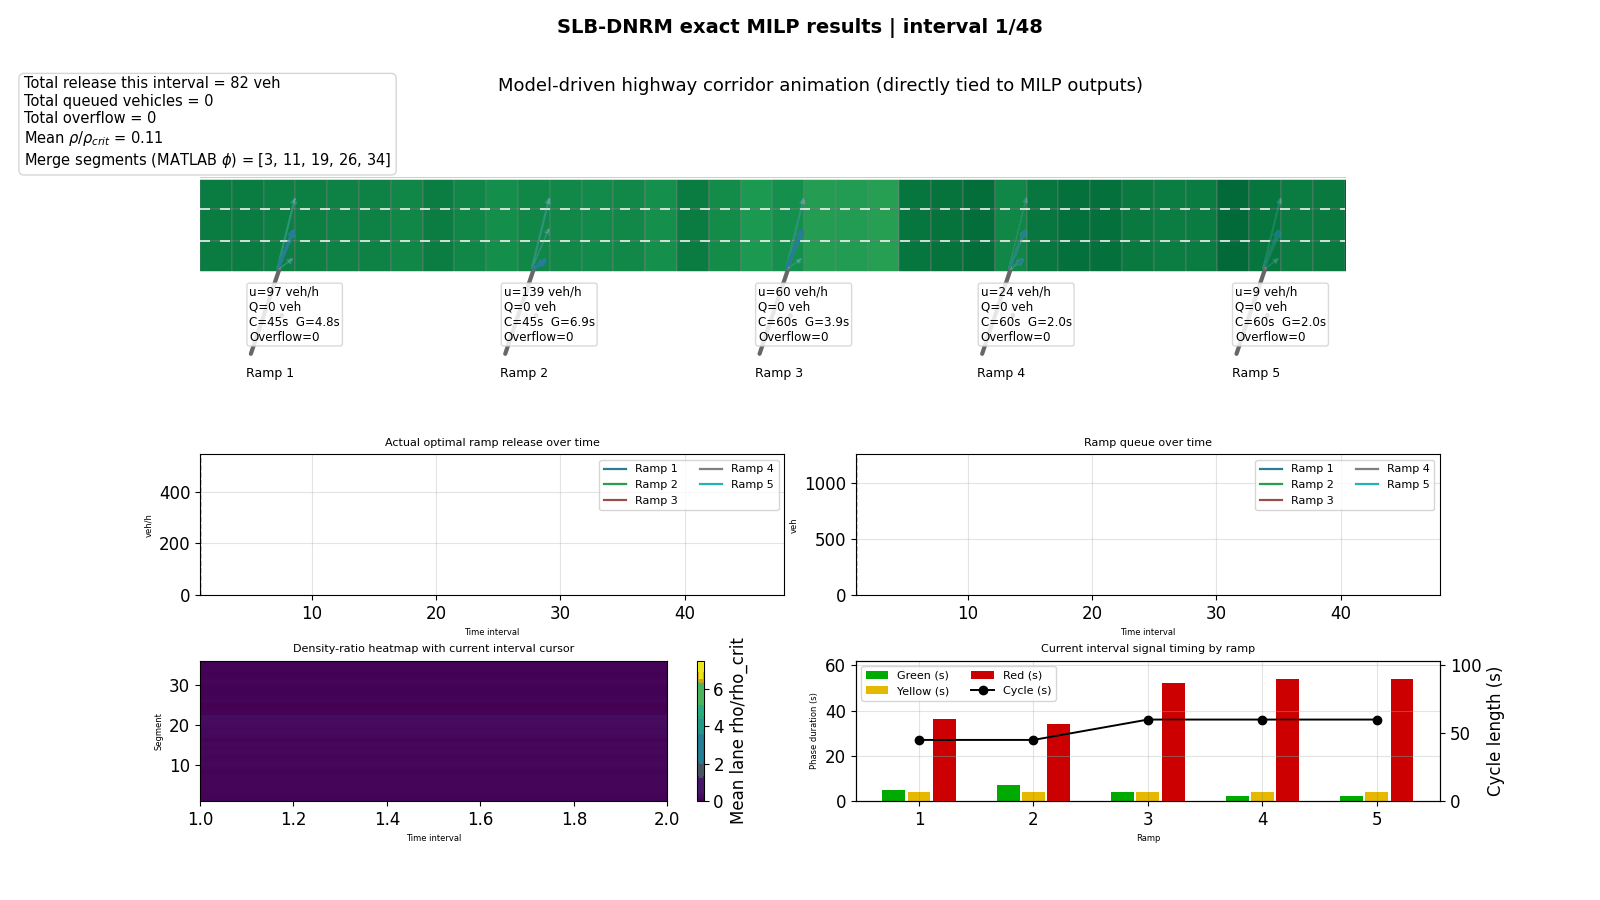

In [13]:
from IPython.display import Image, display
display(Image(filename='SLB_DNRM_Python_ExactOutputs/SLB_DNRM_exact_animation.gif'))

In [14]:
import pandas as pd
pd.read_csv('SLB_DNRM_Python_ExactOutputs/SLB_DNRM_Rolling_Ramp_Summary.csv').head()

,Ramp,RampLane,TotalDemandVeh,ServedVeh,UnmetVeh,ServicePercent,MaxQueueVeh,MaxOverflowVeh,IdleCapacityVeh,DownstreamSlackVeh,AvgRhoOverCriticalAtMerge,MaxRhoOverCriticalAtMerge,WindowServiceSlackVeh,ZeroReleaseIntervals
0,1,1,2627.118383,2098,832,79.835156,636,273,120,0,4.437667,7.5,345.848532,16
1,2,1,4275.401795,3442,1392,80.494104,1137,547,83,1,4.665443,7.5,355.695371,11
2,3,1,3277.896947,3143,656,95.871284,532,80,63,25,3.783317,7.5,83.397780,8
3,4,1,4982.634511,4784,1100,95.998046,942,255,10,172,3.372611,7.5,57.482288,0
4,5,1,3581.949227,3582,171,100.000000,170,0,15,0,0.739484,1.0,0.000000,0
